# Graph-Grounded Issue Localization: Q1-Ready Experimental Pipeline

**Primary research question:** when and why does repository structure improve software issue localization, and does the same structural information help constrained LLM agents?

This upgraded notebook preserves the original BM25 → BM25+signals → GraphRank ladder, expands evaluation to the full available task set, adds held-out graph-weight selection, robustness/sensitivity analyses, graph-component diagnostics, task-level analysis, and controlled A/S/D agent evaluation when the model environment is available.

**No result is simulated or back-filled. If an experiment cannot run, it is explicitly marked unavailable.**

---
**Update (Part B added).** This notebook now has two parts. **Part A** (sections 0-7, unchanged) is the issue-localization study. **Part B** (sections B1-B9, at the end) adds *BlastRadius*: graph-based change-impact analysis, a new task of ranking the tests a patch affects, with its own baselines, ablations and optional Gemma reranker. Part B does not need the LLM, so it runs even though Phase 2 is currently unavailable in this environment (see the wheelhouse diagnostic in the second code cell).


In [1]:
#pip install -U transformers torch accelerate


In [2]:
from pathlib import Path

W = Path("/kaggle/input/datasets/metric/gemma-4-developer-agent-wheelhouse")

print("Exists:", W.exists())

for f in W.glob("*.whl"):
    print(f.name)

Exists: True
safetensors-0.8.0-cp310-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl
mistral_common-1.11.7-py3-none-any.whl
partial_json_parser-0.2.1.1.post7-py3-none-any.whl
compressed_tensors-0.15.0.1-py3-none-any.whl
setproctitle-1.3.7-cp312-cp312-manylinux1_x86_64.manylinux_2_28_x86_64.manylinux_2_5_x86_64.whl
model_hosting_container_standards-0.1.16-py3-none-any.whl
interegular-0.3.3-py37-none-any.whl
outlines_core-0.2.11-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl
msgspec-0.21.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl
pycountry-26.2.16-py3-none-any.whl
adk_eval_core-0.1.0-py3-none-any.whl
quack_kernels-0.6.4-py3-none-any.whl
pydantic_extra_types-2.11.2-py3-none-any.whl
transformers-5.13.1-py3-none-any.whl
apache_tvm_ffi-0.1.13.post3-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl
google_adk-1.36.1-py3-none-any.whl
google_genai-2.11.0-py3-none-any.whl
gguf-0.19.0-py3-none-any.whl
cbor2-6.1.4-cp312-cp312-manyli

In [3]:
!pip install --no-index --no-deps \
  /kaggle/input/datasets/metric/gemma-4-developer-agent-wheelhouse/vllm-0.19.1-cp38-abi3-manylinux_2_31_x86_64.whl

Processing /kaggle/input/datasets/metric/gemma-4-developer-agent-wheelhouse/vllm-0.19.1-cp38-abi3-manylinux_2_31_x86_64.whl


In [4]:
# Offline dependency repair for Phase 2. Never use the internet in the experiment environment.
# The supplied wheelhouse contains msgspec. Install only if a compatible wheel exists.
import sys, subprocess
#WHEELHOUSE = Path("/kaggle/input/datasets/metric/gemma-4-developer-agent-wheelhouse")
WHEELHOUSE = Path("/kaggle/input/datasets/metric/gemma-4-developer-agent-wheelhouse")
print("Python:", sys.version)
print("Wheelhouse exists:", WHEELHOUSE.exists())
if WHEELHOUSE.exists():
    wheels = sorted(WHEELHOUSE.glob("msgspec-*.whl"))
    print("msgspec wheels:", [w.name for w in wheels])
    if wheels:
        r = subprocess.run([sys.executable,"-m","pip","install","--no-index","--no-deps",str(wheels[0])],capture_output=True,text=True)
        print(r.stdout[-1200:]); print(r.stderr[-1200:])
        try:
            import msgspec; print("msgspec:", msgspec.__version__)
        except Exception as e: print("msgspec unavailable:",repr(e))
else:
    print("Attach the competition wheelhouse dataset before Phase 2.")

# --- Diagnostic: interpreter tag vs wheel tags (msgspec failed to install in the previous run)
import re, shutil
_tag = f"cp{sys.version_info.major}{sys.version_info.minor}"
_wh_tags = sorted({m.group(1) for w in WHEELHOUSE.glob("*.whl") for m in [re.search(r"-(cp\d+)-cp\d+", w.name)] if m}) if WHEELHOUSE.exists() else []
print("Interpreter tag:", _tag, "| wheelhouse CPython-specific tags:", _wh_tags, "| python3.12 on PATH:", shutil.which("python3.12"))
if _wh_tags and _tag not in _wh_tags:
    print("MISMATCH: wheelhouse built for", _wh_tags, "but this kernel is", _tag, "-> msgspec (and so vLLM) cannot install here. "
          "Phase 2 needs an environment whose Python matches the wheelhouse. Part A baselines and Part B run without the LLM.")


Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
Wheelhouse exists: True
msgspec wheels: ['msgspec-0.21.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl']

ERROR: msgspec-0.21.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl is not a supported wheel on this platform.

msgspec unavailable: ModuleNotFoundError("No module named 'msgspec'")
Interpreter tag: cp313 | wheelhouse CPython-specific tags: ['cp312'] | python3.12 on PATH: /usr/bin/python3.12
MISMATCH: wheelhouse built for ['cp312'] but this kernel is cp313 -> msgspec (and so vLLM) cannot install here. Phase 2 needs an environment whose Python matches the wheelhouse. Part A baselines and Part B run without the LLM.


## 0. Setup and configuration
Imports, helper to locate inputs, and the single `CFG` dictionary that controls the whole run.

In [5]:
import os, sys, json, time, platform, subprocess, zipfile, hashlib, inspect, copy, random
from pathlib import Path
import numpy as np

INPUT_ROOT = Path(os.environ.get("GGIL_INPUT_ROOT", "/kaggle/input"))
def walk_find(pred, root=INPUT_ROOT, maxdepth=7):
    hits=[]
    if not root.exists(): return hits
    base=len(root.parts)
    for dp,dns,fns in os.walk(root):
        if len(Path(dp).parts)-base >= maxdepth: dns[:]=[]
        for n in dns+fns:
            p=Path(dp)/n
            if pred(p): hits.append(p)
    return sorted(hits)

CFG=dict(
    TOOLKIT="/kaggle/input/datasets/manishverma649/ggil-toolkit/ggil_pkg",
    TASKS="/kaggle/input/competitions/gemma-4-developer-agent/tasks.jsonl",
    SNAPSHOTS="/kaggle/input/competitions/gemma-4-developer-agent/snapshots",
    ID_FILE=os.environ.get("GGIL_IDS"),
    LIMIT=int(os.environ.get("GGIL_LIMIT",129)),
    FIELD_MAP={}, ALLOW_UNVERIFIED=False,
    MODEL_PATH=os.environ.get("GGIL_MODEL"), VARIANTS=["A","S","D"],
    MAX_STEPS=12, MAX_MODEL_LEN=16384, MAX_NEW_TOKENS=512, TEMPERATURE=0.0,
    GPU_MEM_UTIL=0.80, TENSOR_PARALLEL_SIZE=int(os.environ.get("GGIL_TP",4)),
    MAX_MINUTES=int(os.environ.get("GGIL_MAX_MINUTES",480)),
    BOOTSTRAP=5000, RANDOM_SEED=2026, PROPAGATION_WEIGHT=0.30,
    ALPHA_GRID=[0.0,0.1,0.2,0.3,0.4,0.5,0.7,0.9], MAX_HOPS=4,
    OUT=Path(os.environ.get("GGIL_OUT","/kaggle/working/ggil_results_q1")), PACK=False)
CFG["OUT"].mkdir(parents=True,exist_ok=True)
random.seed(CFG["RANDOM_SEED"])
print({k:(str(v) if isinstance(v,Path) else v) for k,v in CFG.items() if k!="FIELD_MAP"})


{'TOOLKIT': '/kaggle/input/datasets/manishverma649/ggil-toolkit/ggil_pkg', 'TASKS': '/kaggle/input/competitions/gemma-4-developer-agent/tasks.jsonl', 'SNAPSHOTS': '/kaggle/input/competitions/gemma-4-developer-agent/snapshots', 'ID_FILE': None, 'LIMIT': 129, 'ALLOW_UNVERIFIED': False, 'MODEL_PATH': None, 'VARIANTS': ['A', 'S', 'D'], 'MAX_STEPS': 12, 'MAX_MODEL_LEN': 16384, 'MAX_NEW_TOKENS': 512, 'TEMPERATURE': 0.0, 'GPU_MEM_UTIL': 0.8, 'TENSOR_PARALLEL_SIZE': 4, 'MAX_MINUTES': 480, 'BOOTSTRAP': 5000, 'RANDOM_SEED': 2026, 'PROPAGATION_WEIGHT': 0.3, 'ALPHA_GRID': [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.7, 0.9], 'MAX_HOPS': 4, 'OUT': '/kaggle/working/ggil_results_q1', 'PACK': False}


## Q1 study design

**RQ1:** Do issue-specific traceback/identifier signals improve lexical retrieval?

**RQ2:** Does graph propagation add value beyond those signals?

**RQ3:** How sensitive are results to propagation weight, graph relation type, graph noise, and snapshot quality?

**RQ4:** When does graph information help across task and repository characteristics?

**RQ5:** Does graph access improve a small LLM agent under the same context and tool budget?

**RQ6:** Do static graph hints and interactive graph tools differ in accuracy and search efficiency?

The primary run uses all resolvable tasks available in the task file. A clean-snapshot sensitivity analysis excludes tasks whose patch references files absent from the pre-fix snapshot.

RQ7-RQ11 (change-impact ranking) are defined in Part B.


## 1. Load the toolkit and self-test it

In [6]:
tk = CFG["TOOLKIT"]
if not tk:
    c = walk_find(lambda p: p.name == "ggil_toolkit.zip") or walk_find(lambda p: p.is_dir() and (p / "ggil" / "__init__.py").exists())
    assert c, "Toolkit not found: add a dataset containing ggil_toolkit.zip, or set CFG['TOOLKIT']."
    tk = str(c[0])
tk = Path(tk)

if tk.suffix == ".zip":
    dst = Path("/tmp/ggil_src"); dst.mkdir(exist_ok=True)
    zipfile.ZipFile(tk).extractall(dst)
    pkg_root = next(dst.rglob("ggil/__init__.py")).parent.parent
else:
    pkg_root = tk if (tk / "ggil").exists() else tk.parent
sys.path.insert(0, str(pkg_root))
import ggil
from ggil import (build_graph, GraphTools, gold_from_patch, parse_patch, score_instance,
                  aggregate, paired_bootstrap)
from ggil.agent import TaskCtx, run_variant
print("toolkit:", pkg_root)

try:
    import pytest  # noqa
    r = subprocess.run([sys.executable, "-m", "pytest", "-q", "-x", str(pkg_root / "tests")], capture_output=True, text=True, cwd=pkg_root)
    print("self-tests:", r.stdout.strip().splitlines()[-1] if r.stdout.strip() else r.stderr[-300:])
    assert r.returncode == 0, r.stdout[-2000:]
except ImportError:
    print("pytest not installed - skipping self-tests")

toolkit: /kaggle/input/datasets/manishverma649/ggil-toolkit/ggil_pkg
self-tests: 16 passed, 1 warning in 0.19s


## 2. Load tasks
The loader auto-detects common field names (`instance_id`/`id`, `problem_statement`/`issue`/..., `patch`/`gold_patch`/...). It prints what it found so you can verify the mapping.

In [7]:
# --- Task loader (handles SWE-bench-style repo + base_commit layouts); overrides the toolkit's older loader. ---
_HOT = Path('/tmp/ggil_hot'); _HOT.mkdir(exist_ok=True)
(_HOT / 'ggil_data_v2.py').write_text(r'''"""data.py - tolerant task loader (jsonl / json) with snapshot resolution.

Supports SWE-bench-style rows (instance_id, repo, base_commit, problem_statement, patch) and
several snapshot layouts under `snapshots_root`:

  per-instance   <snap>/<instance_id>/            (dir)  or  <snap>/<instance_id>.tar.gz|.tgz|.tar|.zip
                 <snap>/<instance_id>/repo/
                 <snap>/<repo_key>/<instance_id>/
  git@commit     <snap>/<repo_key>/  is a git clone (or bare mirror) -> `git archive <base_commit>`
  per-commit     <snap>/<repo_key>/<base_commit>/  (full or 7/12-char prefix)
  per-repo       <snap>/<repo_key>/  plain checkout, commit NOT verifiable  (flagged!)
  fuzzy          any dir/archive (depth<=3) whose normalized name equals/contains the instance id

`repo_key` candidates come from the repo id ("owner/name" -> owner__name, owner_name, name, ...)
and from the instance-id prefix ("fastapi_11194" -> "fastapi").
Each task gets `snapshot_kind` so you can see how it was resolved; "per-repo" means the commit
could not be verified and gold line numbers may be off.
"""
from __future__ import annotations

import json, os, re, shutil, subprocess, tarfile, zipfile
from collections import Counter
from pathlib import Path
from typing import Dict, List, Optional, Tuple

FIELD_CANDIDATES = {
    "instance_id": ["instance_id", "id", "task_id"],
    "issue": ["problem_statement", "issue", "issue_text", "issue_body", "text", "description", "prompt"],
    "patch": ["patch", "gold_patch", "fix_patch", "solution_patch", "golden_patch"],
    "repo": ["repo_path", "repo_dir", "snapshot", "snapshot_path", "repo_root", "path", "workdir"],  # a PATH
    "repo_id": ["repo", "repository", "repo_name", "repo_slug"],                                     # "owner/name"
    "commit": ["base_commit", "commit", "base_sha", "sha"],
}
ARCHIVE_SUFFIXES = (".tar.gz", ".tgz", ".tar", ".zip")


def _read_rows(p: Path) -> List[dict]:
    txt = p.read_text(encoding="utf-8")
    if p.suffix == ".json":
        d = json.loads(txt)
        return d if isinstance(d, list) else d.get("tasks", d.get("instances", []))
    return [json.loads(l) for l in txt.splitlines() if l.strip()]


def _pick(row: dict, key: str, field_map: Dict[str, str]):
    if key in field_map:
        return row.get(field_map[key])
    for c in FIELD_CANDIDATES[key]:
        if row.get(c) not in (None, ""):
            return row[c]
    return None


def _norm(s: str) -> str:
    return re.sub(r"[^a-z0-9]+", "", s.lower())


def _has_py(d: Path, limit: int = 4000) -> bool:
    n = 0
    for _, _, fns in os.walk(d):
        if any(f.endswith(".py") for f in fns):
            return True
        n += 1
        if n > limit:
            break
    return False


def _git_dir(p: Path) -> Optional[Path]:
    if (p / ".git").exists():
        return p / ".git" if (p / ".git").is_dir() else None   # worktree-file .git not supported
    if (p / "HEAD").is_file() and (p / "objects").is_dir():
        return p                                                # bare repo / mirror
    return None


def _git_archive(cand: Path, commit: str, out: Path) -> bool:
    gd = _git_dir(cand)
    if gd is None or not commit:
        return False
    out.mkdir(parents=True, exist_ok=True)
    tmp = out.parent / f".{out.name}.tar"
    r = subprocess.run(["git", "-c", "safe.directory=*", "--git-dir", str(gd), "archive", "--format=tar",
                        "-o", str(tmp), commit], capture_output=True)
    if r.returncode != 0:
        shutil.rmtree(out, ignore_errors=True)
        return False
    with tarfile.open(tmp) as tf:
        _safe_extract(tf, out)
    tmp.unlink(missing_ok=True)
    return _has_py(out)


def _safe_extract(tf: tarfile.TarFile, out: Path) -> None:
    try:
        tf.extractall(out, filter="data")        # Python >= 3.12 (and backports): blocks path traversal
    except TypeError:
        tf.extractall(out)


def _unpack(p: Path, work: Path, tag: str) -> Optional[Path]:
    out = work / tag
    if not out.exists():
        out.mkdir(parents=True)
        try:
            if p.name.endswith(".zip"):
                zipfile.ZipFile(p).extractall(out)
            else:
                with tarfile.open(p) as tf:
                    _safe_extract(tf, out)
        except Exception:
            shutil.rmtree(out, ignore_errors=True)
            return None
    return _descend(out)


def _descend(d: Path) -> Path:
    """Archives often wrap everything in one top-level folder."""
    subs = [x for x in d.iterdir() if not x.name.startswith(".")]
    if len(subs) == 1 and subs[0].is_dir():
        return subs[0]
    return d


def _repo_keys(repo_id: Optional[str], iid: str) -> List[str]:
    keys: List[str] = []
    if repo_id:
        owner, _, name = repo_id.rpartition("/")
        keys += [repo_id, repo_id.replace("/", "__"), repo_id.replace("/", "_"), repo_id.replace("/", "-"), name]
        if owner:
            keys.append(owner)
    if "_" in iid:
        keys.append(iid.rsplit("_", 1)[0])
    return list(dict.fromkeys(k for k in keys if k))


def _scan_index(snap: Path, maxdepth: int = 3, cap: int = 5000) -> List[Path]:
    out, base = [], len(snap.parts)
    for dp, dns, fns in os.walk(snap):
        depth = len(Path(dp).parts) - base
        dns[:] = [d for d in dns if d != ".git"] if depth < maxdepth else []
        for n in dns + [f for f in fns if f.endswith(ARCHIVE_SUFFIXES)]:
            out.append(Path(dp) / n)
        if len(out) > cap:
            break
    return out


def resolve_snapshot(snap: Optional[Path], tasks_dir: Path, work: Path, iid: str, repo_path: Optional[str],
                     repo_id: Optional[str], commit: Optional[str], _index_cache: dict) -> Tuple[Optional[Path], str]:
    # 0. explicit path column
    if repo_path:
        rp = Path(str(repo_path))
        for c in [rp, tasks_dir / rp] + ([snap / rp] if snap else []):
            if c.is_dir():
                return _descend(c) if not _has_py(c) else c, "per-instance"
            if c.is_file() and c.name.endswith(ARCHIVE_SUFFIXES):
                d = _unpack(c, work, iid)
                if d:
                    return d, "per-instance"
    roots = ([snap] if snap else []) + [tasks_dir / "snapshots"]
    keys = _repo_keys(repo_id, iid)
    for root in roots:
        if not root.exists():
            continue
        # 1. per-instance
        per = [root / iid, root / iid / "repo"] + [root / f"{iid}{s}" for s in ARCHIVE_SUFFIXES] + \
              [root / k / iid for k in keys]
        for c in per:
            if c.is_dir() and _has_py(c):
                return c, "per-instance"
            if c.is_file() and c.name.endswith(ARCHIVE_SUFFIXES):
                d = _unpack(c, work, iid)
                if d and _has_py(d):
                    return d, "per-instance"
        # 2. repo-keyed: git@commit, per-commit folder, plain checkout
        for k in keys:
            for c in (root / k, root / k / "repo", root / k.replace("__", "/")):
                if not c.is_dir():
                    continue
                if commit and _git_dir(c):
                    out = work / f"{iid}_git"
                    if out.exists() and _has_py(out) or _git_archive(c, commit, out):
                        return out, "git@base_commit"
                if commit:
                    for sub in (commit, commit[:12], commit[:7]):
                        if (c / sub).is_dir() and _has_py(c / sub):
                            return c / sub, "per-commit"
                if _has_py(c):
                    return c, "per-repo (commit NOT verified)"
        # 3. fuzzy name match
        idx = _index_cache.setdefault(str(root), _scan_index(root))
        ni = _norm(iid)
        for p in idx:
            nm = _norm(p.name.split(".")[0] if p.is_file() else p.name)
            if nm == ni or (len(ni) >= 6 and ni in nm):
                if p.is_dir() and _has_py(p):
                    return p, "fuzzy"
                if p.is_file():
                    d = _unpack(p, work, iid)
                    if d and _has_py(d):
                        return d, "fuzzy"
    return None, "unresolved"


def describe_layout(snap: Optional[str | Path], max_entries: int = 40, depth: int = 2) -> str:
    if not snap or not Path(snap).exists():
        return f"(snapshots path does not exist: {snap})"
    snap, lines, base = Path(snap), [], len(Path(snap).parts)
    for dp, dns, fns in os.walk(snap):
        d = len(Path(dp).parts) - base
        dns[:] = sorted(x for x in dns if x != ".git") if d < depth else []
        for n in sorted(dns) + sorted(fns)[:5]:
            lines.append("  " * (d + 1) + n + ("/" if n in dns else ""))
        if len(lines) >= max_entries:
            lines.append("  ... (truncated)")
            break
    return f"{snap}\n" + "\n".join(lines[:max_entries + 1])


def load_ids(path: Optional[str]) -> Optional[List[str]]:
    if not path or not Path(path).exists():
        return None
    return [l.strip() for l in Path(path).read_text().splitlines() if l.strip() and not l.startswith("#")]


def load_tasks(tasks_path: str | Path, snapshots_root: Optional[str | Path] = None,
               ids: Optional[List[str]] = None, limit: Optional[int] = None,
               field_map: Optional[Dict[str, str]] = None, work_dir: str | Path = "/tmp/ggil_snapshots"):
    tasks_path, work = Path(tasks_path), Path(work_dir)
    work.mkdir(parents=True, exist_ok=True)
    field_map = field_map or {}
    snap = Path(snapshots_root) if snapshots_root else None
    rows = _read_rows(tasks_path)
    if ids:
        order = {i: n for n, i in enumerate(ids)}
        rows = sorted((r for r in rows if str(_pick(r, "instance_id", field_map)) in order),
                      key=lambda r: order[str(_pick(r, "instance_id", field_map))])
    tasks, cache = [], {}
    report = {"rows": len(rows), "no_issue": 0, "no_patch": 0, "no_repo": 0, "kinds": Counter(),
              "columns": sorted(rows[0]) if rows else []}
    for r in rows:
        iid = str(_pick(r, "instance_id", field_map))
        issue, patch = _pick(r, "issue", field_map), _pick(r, "patch", field_map)
        repo_path, repo_id, commit = _pick(r, "repo", field_map), _pick(r, "repo_id", field_map), _pick(r, "commit", field_map)
        # a mapped 'repo' like "owner/name" is an id, not a path: still tried as a path first, harmlessly
        root, kind = resolve_snapshot(snap, tasks_path.parent, work, iid, repo_path, repo_id or repo_path, commit, cache)
        report["no_issue"] += issue is None
        report["no_patch"] += patch is None
        report["no_repo"] += root is None
        report["kinds"][kind] += 1
        tasks.append({"instance_id": iid, "issue": issue or "", "patch": patch, "repo_root": root,
                      "snapshot_kind": kind, "base_commit": commit, "repo_id": repo_id, "raw": r})
        if limit and len(tasks) >= limit:
            break
    report["kinds"] = dict(report["kinds"])
    if report["no_repo"]:
        t = next((t for t in tasks if t["repo_root"] is None), None)
        report["unresolved_example"] = {k: t[k] for k in ("instance_id", "repo_id", "base_commit")} if t else None
        report["layout"] = describe_layout(snap)
    return tasks, report
''')
sys.path.insert(0, str(_HOT))
import importlib, ggil_data_v2
importlib.reload(ggil_data_v2)
from ggil_data_v2 import load_tasks, load_ids
print('task loader: updated version active')

task loader: updated version active


In [8]:
tp = CFG["TASKS"]
if not tp:
    cands = walk_find(lambda p: p.is_file() and p.suffix in (".jsonl", ".json") and "task" in p.name.lower())
    assert cands, "No tasks file found: add your task data or set CFG['TASKS']."
    if len(cands) > 1:
        print("Several task files found, using the first. Set CFG['TASKS'] to choose:\n  " + "\n  ".join(map(str, cands)))
    tp = str(cands[0])
snap = CFG["SNAPSHOTS"]
if not snap:
    s = walk_find(lambda p: p.is_dir() and p.name in ("snapshots", "repos"))
    snap = str(s[0]) if s else None
ids = load_ids(CFG["ID_FILE"])
tasks, rep = load_tasks(tp, snap, ids=ids, limit=CFG["LIMIT"], field_map=CFG["FIELD_MAP"])
print("tasks file :", tp, "\nsnapshots  :", snap, "\ncolumns    :", rep["columns"])
print({k: v for k, v in rep.items() if k not in ("columns", "layout", "unresolved_example")})

if rep["no_repo"]:
    print("\n--- Some tasks have no snapshot. Example of an unresolved task:", rep.get("unresolved_example"))
    print("--- What the snapshots folder looks like (use this to tell me / set CFG):")
    print(rep.get("layout"))

assert tasks, "No tasks loaded."
assert rep["no_issue"] < len(tasks), "No issue text detected - set CFG['FIELD_MAP']['issue']."
usable = [t for t in tasks if t["repo_root"] is not None]
assert usable, ("No repo snapshots resolved. Read the layout printed above: the loader supports per-task folders/archives, "
                "git clones or mirrors (checked out at base_commit), and per-commit folders. Tell me the layout if it is different.")

unverified = [t for t in usable if "NOT verified" in t["snapshot_kind"]]
if unverified and not CFG.get("ALLOW_UNVERIFIED", False):
    print(f"WARNING: {len(unverified)} tasks only have a per-repo checkout whose commit cannot be verified against base_commit; "
          "gold line numbers may not match. They are EXCLUDED. Set CFG['ALLOW_UNVERIFIED']=True to keep them anyway.")
    usable = [t for t in usable if t not in unverified]
    assert usable, "All snapshots are unverified per-repo checkouts - see warning above."
elif unverified:
    print(f"NOTE: keeping {len(unverified)} unverified per-repo snapshots (ALLOW_UNVERIFIED=True) - treat results with caution.")
if len(usable) < len(tasks):
    print(f"{len(tasks) - len(usable)} of {len(tasks)} tasks dropped (no usable snapshot).")
tasks = usable
HAS_GOLD = any(t["patch"] for t in tasks)
print(f"{len(tasks)} tasks | gold patches available: {HAS_GOLD} | snapshot kinds: {rep['kinds']}")

tasks file : /kaggle/input/competitions/gemma-4-developer-agent/tasks.jsonl 
snapshots  : /kaggle/input/competitions/gemma-4-developer-agent/snapshots 
columns    : ['base_commit', 'created_at', 'hints_text', 'instance_id', 'patch', 'problem_statement', 'repo', 'test_patch']
{'rows': 129, 'no_issue': 0, 'no_patch': 0, 'no_repo': 0, 'kinds': {'per-instance': 129}}
129 tasks | gold patches available: True | snapshot kinds: {'per-instance': 129}


## 3. Phase 1 — build graphs, extract gold, check data quality
Graphs must be built on the **pre-fix** snapshot (gold line numbers refer to the old side of the patch). The check below flags snapshots where patched `.py` files are missing, which usually means the wrong commit was checked out.

In [9]:
import pandas as pd

G, t0 = {}, time.time()
for t in tasks:
    g = build_graph(t["repo_root"])
    gold = gold_from_patch(g, t["patch"]) if t["patch"] else None
    mismatch = 0
    if t["patch"]:
        for fp in parse_patch(t["patch"]):
            p = fp.old_path
            if p and not fp.is_new and p.endswith(".py") and p not in g.nodes and "test" not in p.lower():
                mismatch += 1
    G[t["instance_id"]] = dict(graph=g, gold=gold, tools=GraphTools(g), mismatch=mismatch)
print(f"built {len(G)} graphs in {time.time() - t0:.1f}s")

rows = []
for t in tasks:
    d, g = G[t["instance_id"]], G[t["instance_id"]]["graph"]
    st = g.stats()
    rows.append({"instance_id": t["instance_id"], "files": st["nodes"].get("file", 0),
                 "symbols": sum(v for k, v in st["nodes"].items() if k != "file"),
                 "calls_exact": st["edges"].get("calls:exact", 0), "calls_heur": st["edges"].get("calls:heuristic", 0),
                 "gold_files": len(d["gold"].files) if d["gold"] else None,
                 "gold_units": len(d["gold"].units) if d["gold"] else None,
                 "snapshot_mismatch": d["mismatch"]})
stats_df = pd.DataFrame(rows)
display(stats_df.describe().T[["mean", "min", "max"]].round(1))
if HAS_GOLD:
    n_u = int((stats_df.gold_units.fillna(0) > 0).sum()); n_f = int((stats_df.gold_files.fillna(0) > 0).sum())
    print(f"tasks with gold files: {n_f}/{len(tasks)} | with gold function-level units: {n_u}/{len(tasks)} "
          f"(function-level metrics are computed only on these {n_u})")
    bad = int((stats_df.snapshot_mismatch > 0).sum())
    if bad:
        print(f"WARNING: {bad} tasks have patched .py files missing from the snapshot - check that snapshots are the PRE-fix commit.")

built 129 graphs in 261.7s


,mean,min,max
files,690.6,35.0,1279.0
symbols,3479.7,727.0,5845.0
calls_exact,2997.9,816.0,3635.0
calls_heur,1571.4,299.0,2185.0
gold_files,1.8,0.0,20.0
gold_units,4.1,0.0,139.0
snapshot_mismatch,0.4,0.0,23.0


tasks with gold files: 128/129 | with gold function-level units: 121/129 (function-level metrics are computed only on these 121)


## 4. Phase 1 — no-LLM baselines and graph ablation ladder

In [10]:
def score_rows(preds):
    """preds: {iid: (pred_files, pred_units)} -> list of per-instance metric dicts (gold-bearing tasks only)."""
    out = []
    for t in tasks:
        d = G[t["instance_id"]]
        if d["gold"] is None or not (d["gold"].files or d["gold"].units):
            continue
        pf, pu = preds.get(t["instance_id"], ([], []))
        m = score_instance(d["graph"], d["gold"], pf or None, pu)
        m["instance_id"] = t["instance_id"]
        out.append(m)
    return out

RESULTS = {}     # system -> per-instance rows
EXTRA = {}       # system -> {"answered": .., "tool_calls": ..}
if HAS_GOLD:
    ladder = {"BM25": dict(propagate=0.0, use_signals=False),
              "BM25+signals": dict(propagate=0.0, use_signals=True),
              "GraphRank": dict(propagate=0.3, use_signals=True)}
    for name, kw in ladder.items():
        preds = {}
        for t in tasks:
            r = G[t["instance_id"]]["tools"].rank(t["issue"], **kw)
            preds[t["instance_id"]] = ([f for f, _ in r.files[:10]], [u for u, _ in r.units[:10]])
        RESULTS[name] = score_rows(preds)
    print("done:", list(RESULTS))
else:
    print("No gold patches in this task file: scoring skipped (rankings can still be produced for submission).")

done: ['BM25', 'BM25+signals', 'GraphRank']


## 4A. Primary/clean cohorts and held-out split

A deterministic 80/20 task split is used only for selecting the graph propagation weight. The selected value is then frozen before held-out evaluation. The original 0.30 setting remains a non-tuned reference.


In [11]:
import hashlib

def split_label(iid):
    x=int(hashlib.sha256((iid+"::"+str(CFG["RANDOM_SEED"])).encode()).hexdigest()[:8],16)/0xFFFFFFFF*100
    return "dev" if x<20 else "test"

cohort_df=stats_df.copy()
cohort_df["cohort"]=cohort_df["instance_id"].map(split_label)
cohort_df["clean_snapshot"]=cohort_df["snapshot_mismatch"].eq(0)
display(cohort_df.groupby(["cohort","clean_snapshot"]).size().rename("n").reset_index())
print("Resolvable:",len(cohort_df)," Clean:",int(cohort_df.clean_snapshot.sum()))


,cohort,clean_snapshot,n
0,dev,False,1
1,dev,True,24
2,test,False,10
3,test,True,94


Resolvable: 129  Clean: 118


## 4B. Propagation-weight sensitivity

The original notebook fixed the graph weight at 0.30. We now evaluate a prespecified grid on development tasks and freeze the best value by function-level Acc@1, with MRR as the tie-breaker.


In [12]:
def score_rows_for_ids(preds,ids):
    ids=set(ids); out=[]
    for t in tasks:
        iid=t["instance_id"]
        if iid not in ids: continue
        d=G[iid]
        if d["gold"] is None or not (d["gold"].files or d["gold"].units): continue
        pf,pu=preds.get(iid,([],[]))
        m=score_instance(d["graph"],d["gold"],pf or None,pu); m["instance_id"]=iid; out.append(m)
    return out

def run_ranker(propagate,use_signals=True,ids=None):
    ids=set(ids) if ids is not None else {t["instance_id"] for t in tasks}; preds={}
    for t in tasks:
        iid=t["instance_id"]
        if iid not in ids: continue
        r=G[iid]["tools"].rank(t["issue"],propagate=propagate,use_signals=use_signals)
        preds[iid]=([f for f,_ in r.files[:10]],[u for u,_ in r.units[:10]])
    return score_rows_for_ids(preds,ids)

split_map=dict(zip(cohort_df.instance_id,cohort_df.cohort))
dev_ids=[i for i,v in split_map.items() if v=="dev"]; test_ids=[i for i,v in split_map.items() if v=="test"]
alpha_rows=[]
for alpha in CFG["ALPHA_GRID"]:
    rr=run_ranker(alpha,True,dev_ids); a=aggregate(rr,n_boot=CFG["BOOTSTRAP"])
    if "unit/acc@1" in a:
        alpha_rows.append({"alpha":alpha,"n":a["unit/acc@1"]["n"],"dev_acc1":a["unit/acc@1"]["mean"],"dev_mrr":a.get("unit/mrr",{}).get("mean")})
alpha_df=pd.DataFrame(alpha_rows); display(alpha_df)
selected_alpha=float(alpha_df.sort_values(["dev_acc1","dev_mrr"],ascending=False).iloc[0]["alpha"]) if len(alpha_df) else CFG["PROPAGATION_WEIGHT"]
print("Frozen alpha:",selected_alpha)
frozen_rows=run_ranker(selected_alpha,True,test_ids) if test_ids else []
frozen_agg=aggregate(frozen_rows,n_boot=CFG["BOOTSTRAP"]) if frozen_rows else {}
print("Held-out:",frozen_agg.get("unit/acc@1"))
alpha_df.to_csv(CFG["OUT"]/"propagation_weight_sensitivity.csv",index=False)


,alpha,n,dev_acc1,dev_mrr
0,0.0,24,0.208333,0.259491
1,0.1,24,0.208333,0.267179
2,0.2,24,0.208333,0.272388
3,0.3,24,0.250000,0.307060
4,0.4,24,0.250000,0.310417
5,0.5,24,0.250000,0.311111
6,0.7,24,0.250000,0.288194
7,0.9,24,0.166667,0.231647


Frozen alpha: 0.5
Held-out: {'mean': 0.23711340206185566, 'n': 97, 'ci_lo': 0.15463917525773196, 'ci_hi': 0.32989690721649484}


## 4C. Graph relation ablation

We attempt calls-only, imports-only, inheritance/definition-only, and all-edge conditions. The experiment is capability-adaptive so an unsupported graph representation is reported as unavailable rather than approximated.

**Run note:** in the saved run, calls-only and imports-only scored 0 tasks because the `ggil` graph is not a NetworkX multigraph, so only the all-edge row is real. The relation ablation is repeated properly in Part B (section B4) using the repaired, typed graph.


In [13]:
print("Graph type:",type(next(iter(G.values()))["graph"]))
print("GraphTools.rank:",inspect.signature(GraphTools.rank))
EDGE_KEYS=("type","kind","relation","edge_type")
def edge_type(d):
    if isinstance(d,dict):
        for k in EDGE_KEYS:
            if k in d and d[k] is not None: return str(d[k]).lower()
    return ""
def filtered_graph(g,allowed):
    try:
        h=copy.deepcopy(g)
        if not (hasattr(h,"edges") and hasattr(h,"remove_edge")): return None
        allowed={x.lower() for x in allowed}
        edges=list(h.edges(keys=True,data=True))
        for u,v,k,d in edges:
            typ=edge_type(d)
            if typ and not any(a in typ for a in allowed):
                try: h.remove_edge(u,v,k)
                except TypeError: h.remove_edge(u,v)
        return h
    except Exception as e:
        print("filter failed",repr(e)); return None

relation_sets={"calls_only":["call"],"imports_only":["import"],"inheritance_only":["inherit","defined_in","definition"],"all":[]}
relation_results=[]
for rel,allowed in relation_sets.items():
    preds={}; ran=0
    for t in tasks:
        iid=t["instance_id"]; g0=G[iid]["graph"]
        h=g0 if rel=="all" else filtered_graph(g0,allowed)
        if h is None: continue
        try:
            r=GraphTools(h).rank(t["issue"],propagate=selected_alpha,use_signals=True)
            preds[iid]=([f for f,_ in r.files[:10]],[u for u,_ in r.units[:10]]); ran+=1
        except Exception: pass
    if ran:
        a=aggregate(score_rows(preds),n_boot=CFG["BOOTSTRAP"])
        relation_results.append({"graph":rel,"tasks":ran,"unit_acc1":a.get("unit/acc@1",{}).get("mean"),"unit_mrr":a.get("unit/mrr",{}).get("mean")})
    else: relation_results.append({"graph":rel,"tasks":0,"unit_acc1":None,"unit_mrr":None})
relation_df=pd.DataFrame(relation_results); display(relation_df); relation_df.to_csv(CFG["OUT"]/"graph_relation_ablation.csv",index=False)


Graph type: <class 'ggil.graph.RepoGraph'>
GraphTools.rank: (self, issue_text: 'str', propagate: 'float' = 0.3, seed_k: 'int' = 30, include_tests: 'bool' = False, use_signals: 'bool' = True) -> 'Ranking'


,graph,tasks,unit_acc1,unit_mrr
0,calls_only,0,NaN,NaN
1,imports_only,0,NaN,NaN
2,inheritance_only,0,NaN,NaN
3,all,129,0.239669,0.316614


## 4D. Snapshot sensitivity, graph noise, and repository scale


In [14]:
def subset_rows(rows,ids):
    ids=set(ids); return [r for r in rows if r.get("instance_id") in ids]
clean_ids=set(cohort_df.loc[cohort_df.clean_snapshot,"instance_id"])
robust=[]
for system,rows in RESULTS.items():
    for label,ids in [("all",set(cohort_df.instance_id)),("clean_snapshot",clean_ids)]:
        rr=subset_rows(rows,ids)
        if not rr: continue
        a=aggregate(rr,n_boot=CFG["BOOTSTRAP"])
        robust.append({"system":system,"cohort":label,"n":a.get("unit/acc@1",{}).get("n",0),"unit_acc1":a.get("unit/acc@1",{}).get("mean"),"unit_mrr":a.get("unit/mrr",{}).get("mean")})
robust_df=pd.DataFrame(robust); display(robust_df); robust_df.to_csv(CFG["OUT"]/"snapshot_sensitivity.csv",index=False)

stats_df["heuristic_call_fraction"]=stats_df["calls_heur"]/(stats_df["calls_exact"]+stats_df["calls_heur"]).replace(0,np.nan)
stats_df["repo_size_bin"]=pd.qcut(stats_df["files"],q=4,duplicates="drop",labels=["Q1-small","Q2","Q3","Q4-large"])
scale=[]
for b,grp in stats_df.groupby("repo_size_bin",observed=True):
    ids=set(grp.instance_id)
    for system in ["BM25+signals","GraphRank"]:
        rr=subset_rows(RESULTS.get(system,[]),ids)
        if not rr: continue
        a=aggregate(rr,n_boot=CFG["BOOTSTRAP"])
        scale.append({"repo_size_bin":str(b),"system":system,"n":a.get("unit/acc@1",{}).get("n",0),"unit_acc1":a.get("unit/acc@1",{}).get("mean")})
scale_df=pd.DataFrame(scale); display(scale_df); scale_df.to_csv(CFG["OUT"]/"repository_scale_analysis.csv",index=False)


,system,cohort,n,unit_acc1,unit_mrr
0,BM25,all,121,0.132231,0.208222
1,BM25,clean_snapshot,111,0.144144,0.216470
2,BM25+signals,all,121,0.223140,0.288584
3,BM25+signals,clean_snapshot,111,0.243243,0.304072
4,GraphRank,all,121,0.247934,0.324823
5,GraphRank,clean_snapshot,111,0.270270,0.336883


,repo_size_bin,system,n,unit_acc1
0,Q1-small,BM25+signals,43,0.325581
1,Q1-small,GraphRank,43,0.348837
2,Q2,BM25+signals,17,0.235294
3,Q2,GraphRank,17,0.235294
4,Q3,BM25+signals,31,0.161290
5,Q3,GraphRank,31,0.193548
6,Q4-large,BM25+signals,30,0.133333
7,Q4-large,GraphRank,30,0.166667


## 4E. Task-level graph gains


In [15]:
def metric_map(rows, metric):
    return {r["instance_id"]: r.get(metric) for r in rows}

if "GraphRank" in RESULTS and "BM25+signals" in RESULTS:
    gm = metric_map(RESULTS["GraphRank"], "unit/acc@1")
    sm = metric_map(RESULTS["BM25+signals"], "unit/acc@1")
    
    # Filter out entries where either score is None
    valid_ids = [i for i in sorted(set(gm) & set(sm)) if gm[i] is not None and sm[i] is not None]
    
    tg = pd.DataFrame([{
        "instance_id": i, 
        "graph_minus_signals": float(gm[i]) - float(sm[i]) 
    } for i in valid_ids])
    
    tg = tg.merge(stats_df[["instance_id", "files", "symbols", "calls_exact", "calls_heur", "heuristic_call_fraction"]], on="instance_id", how="left")
    tg["graph_helps"] = tg.graph_minus_signals > 0
    display(tg.head(20))
    print("wins/ties/losses:", int((tg.graph_minus_signals > 0).sum()), int((tg.graph_minus_signals == 0).sum()), int((tg.graph_minus_signals < 0).sum()))
    tg.to_csv(CFG["OUT"] / "task_level_graph_gains.csv", index=False)

,instance_id,graph_minus_signals,files,symbols,calls_exact,calls_heur,heuristic_call_fraction,graph_helps
0,fastapi_11194,0.0,1135,4371,2962,879,0.228847,False
1,fastapi_11355,0.0,1202,5020,3309,1197,0.265646,False
2,fastapi_12942,0.0,1142,4439,2998,884,0.227718,False
3,fastapi_13207,0.0,1198,4913,3273,1194,0.267293,False
4,fastapi_13537,0.0,1194,4879,3261,1176,0.265044,False
5,fastapi_13713,0.0,1133,4350,2946,879,0.229804,False
6,fastapi_13786,0.0,1186,4830,3236,1175,0.266380,False
7,fastapi_13920,0.0,1255,5497,2994,1729,0.366081,False
8,fastapi_14077,0.0,1133,4350,2946,879,0.229804,False
9,fastapi_14099,0.0,1136,4379,2964,885,0.229930,False


wins/ties/losses: 4 116 1


In [16]:
from pathlib import Path

W = Path("/kaggle/input/datasets/metric/gemma-4-developer-agent-wheelhouse")

print("Exists:", W.exists())

for f in W.glob("*.whl"):
    print(f.name)

Exists: True
safetensors-0.8.0-cp310-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl
mistral_common-1.11.7-py3-none-any.whl
partial_json_parser-0.2.1.1.post7-py3-none-any.whl
compressed_tensors-0.15.0.1-py3-none-any.whl
setproctitle-1.3.7-cp312-cp312-manylinux1_x86_64.manylinux_2_28_x86_64.manylinux_2_5_x86_64.whl
model_hosting_container_standards-0.1.16-py3-none-any.whl
interegular-0.3.3-py37-none-any.whl
outlines_core-0.2.11-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl
msgspec-0.21.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl
pycountry-26.2.16-py3-none-any.whl
adk_eval_core-0.1.0-py3-none-any.whl
quack_kernels-0.6.4-py3-none-any.whl
pydantic_extra_types-2.11.2-py3-none-any.whl
transformers-5.13.1-py3-none-any.whl
apache_tvm_ffi-0.1.13.post3-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl
google_adk-1.36.1-py3-none-any.whl
google_genai-2.11.0-py3-none-any.whl
gguf-0.19.0-py3-none-any.whl
cbor2-6.1.4-cp312-cp312-manyli

## 5. Phase 2 — controlled LLM agents (A / S / D)

All variants share the same model, decoding settings, repository snapshot, context length and maximum step budget. Only graph access changes:

- **A:** file tools only.
- **S:** A + static graph-derived hints.
- **D:** A + interactive graph tools.

The notebook records localization accuracy, answer rate, tool calls and runtime. Failed/unparseable answers remain misses; nothing is back-filled from a ranker.


In [17]:
#pip install /kaggle/input/competitions/gemma-4-developer-agent/wheels/msgspec-0.21.1-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl
!pip install --no-deps msgspec

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.5/230.5 kB 11.7 MB/s eta 0:00:00


In [18]:
LLM_READY,llm,sampling,why_skipped=False,None,None,None
try:
    import torch; n_gpu=torch.cuda.device_count()
except Exception: n_gpu=0
mp=CFG["MODEL_PATH"]
if not mp:
    cands=[p.parent for p in walk_find(lambda p:p.is_file() and p.name=="config.json",maxdepth=7)]
    cands=[c for c in cands if any(c.glob("*.safetensors")) or any(c.glob("*.bin"))]
    if len(cands)==1: mp=str(cands[0])
    elif cands:
        print("Set CFG['MODEL_PATH'] to one of:")
        print("\n  ".join(map(str,cands)))
if n_gpu==0: why_skipped="no GPU visible"
elif not mp: why_skipped="no model found"
else:
    try:
        os.environ.update(HF_HUB_OFFLINE="1",TRANSFORMERS_OFFLINE="1")
        wh=Path("/kaggle/input/datasets/metric/gemma-4-developer-agent-wheelhouse")
     
        if wh.exists(): subprocess.run([sys.executable,"-m","pip","install","--no-index","--find-links",str(wh),"msgspec"],check=False)
        from vllm import LLM,SamplingParams
        tp=min(CFG["TENSOR_PARALLEL_SIZE"],n_gpu)
        llm=LLM(model=mp,tensor_parallel_size=tp,max_model_len=CFG["MAX_MODEL_LEN"],gpu_memory_utilization=CFG["GPU_MEM_UTIL"])
        sampling=SamplingParams(temperature=CFG["TEMPERATURE"],max_tokens=CFG["MAX_NEW_TOKENS"],seed=CFG["RANDOM_SEED"])
        LLM_READY=True
    except Exception as e: why_skipped=f"{type(e).__name__}: {str(e)[:500]}"
print(f"GPUs={n_gpu} | TP={min(CFG['TENSOR_PARALLEL_SIZE'],n_gpu) if n_gpu else 0} | model={mp} | LLM_READY={LLM_READY}")
if why_skipped: print("Phase 2 unavailable:",why_skipped)


Looking in links: /kaggle/input/datasets/metric/gemma-4-developer-agent-wheelhouse
GPUs=2 | TP=2 | model=/kaggle/input/models/thomasplocher/gemma-4-31b-w4a16-ct-mirror/transformers/gemma-4-31b-it-qat-w4a16-ct/1 | LLM_READY=False
Phase 2 unavailable: ImportError: /usr/local/lib/python3.13/dist-packages/vllm/_C.abi3.so: undefined symbol: _ZN3c1013MessageLoggerC1EPKciib


In [19]:
RAW_PREDS = {}
if LLM_READY:
    deadline = time.time() + CFG["MAX_MINUTES"] * 60
    ctxs = [TaskCtx(t["instance_id"], t["issue"], Path(t["repo_root"]), G[t["instance_id"]]["graph"], G[t["instance_id"]]["tools"]) for t in tasks]
    for v in CFG["VARIANTS"]:
        t1 = time.time()
        res = run_variant(llm, sampling, ctxs, v, max_steps=CFG["MAX_STEPS"], deadline=deadline)
        RAW_PREDS[v] = res
        with open(CFG["OUT"] / f"agent_{v}_preds.jsonl", "w") as f:
            for r in res:
                f.write(json.dumps(r) + "\n")
        print(f"variant {v}: {time.time() - t1:.0f}s | answered {sum(r['answered'] for r in res)}/{len(res)} | "
              f"errors { {e: sum(r['error'] == e for r in res) for e in set(r['error'] for r in res if r['error'])} }")
        if HAS_GOLD:
            RESULTS[f"LLM-{v}"] = score_rows({r["instance_id"]: (r["pred_files"], r["pred_units"]) for r in res})
            EXTRA[f"LLM-{v}"] = {"answered": sum(r["answered"] for r in res) / len(res),
                                 "tool_calls": sum(r["tool_calls"] for r in res) / len(res)}
else:
    print("Phase 2 skipped:", why_skipped)

Phase 2 skipped: ImportError: /usr/local/lib/python3.13/dist-packages/vllm/_C.abi3.so: undefined symbol: _ZN3c1013MessageLoggerC1EPKciib


## 5A. Optional agent-budget sensitivity

Set `RUN_BUDGET_SWEEP=True` only after the primary A/S/D run succeeds. This reruns the same variants at fixed step budgets and records localization accuracy, answer rate, tool calls, and runtime. It directly tests whether graph access gives more useful search under constrained interaction budgets.


In [20]:
RUN_BUDGET_SWEEP=False
BUDGETS=[4,8,12,16]
budget_rows=[]
if RUN_BUDGET_SWEEP and LLM_READY:
    ctxs=[TaskCtx(t["instance_id"],t["issue"],Path(t["repo_root"]),G[t["instance_id"]]["graph"],G[t["instance_id"]]["tools"]) for t in tasks]
    for budget in BUDGETS:
        deadline=time.time()+CFG["MAX_MINUTES"]*60
        for v in CFG["VARIANTS"]:
            t0=time.time(); res=run_variant(llm,sampling,ctxs,v,max_steps=budget,deadline=deadline); elapsed=time.time()-t0
            rows=score_rows({r["instance_id"]:(r["pred_files"],r["pred_units"]) for r in res})
            a=aggregate(rows,n_boot=CFG["BOOTSTRAP"])
            budget_rows.append({"variant":v,"max_steps":budget,"unit_acc1":a.get("unit/acc@1",{}).get("mean"),"unit_mrr":a.get("unit/mrr",{}).get("mean"),"answer_rate":sum(r["answered"] for r in res)/len(res),"mean_tool_calls":sum(r["tool_calls"] for r in res)/len(res),"runtime_sec":elapsed})
    budget_df=pd.DataFrame(budget_rows); display(budget_df); budget_df.to_csv(CFG["OUT"]/"agent_budget_sensitivity.csv",index=False)
elif RUN_BUDGET_SWEEP:
    print("Budget sweep requested but Phase 2 is unavailable:",why_skipped)
else:
    print("Budget sweep disabled. Set RUN_BUDGET_SWEEP=True after a successful primary A/S/D run.")


Budget sweep disabled. Set RUN_BUDGET_SWEEP=True after a successful primary A/S/D run.


## 6. Results

In [21]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

SHOW = ["file/acc@1", "file/acc@5", "unit/acc@1", "unit/acc@3", "unit/acc@5", "unit/acc@10", "unit/mrr", "unit/recall@5"]
AGG, table = {}, []
for name, rows in RESULTS.items():
    if not rows:
        continue
    a = aggregate(rows, n_boot=CFG["BOOTSTRAP"])
    AGG[name] = a
    r = {"system": name, "n_file": a.get("file/acc@1", {}).get("n", 0), "n_unit": a.get("unit/acc@1", {}).get("n", 0)}
    for k in SHOW:
        if k in a:
            r[k] = f"{a[k]['mean']:.3f} [{a[k]['ci_lo']:.2f},{a[k]['ci_hi']:.2f}]"
    r.update({k: round(v, 2) for k, v in EXTRA.get(name, {}).items()})
    table.append(r)
if table:
    res_df = pd.DataFrame(table).set_index("system")
    display(res_df)
    res_df.to_csv(CFG["OUT"] / "results_table.csv")
else:
    print("No scored results (no gold patches or no systems ran).")

,n_file,n_unit,file/acc@1,file/acc@5,unit/acc@1,unit/acc@3,unit/acc@5,unit/acc@10,unit/mrr,unit/recall@5
system,,,,,,,,,,
BM25,128,121,"0.305 [0.23,0.38]","0.664 [0.59,0.74]","0.132 [0.07,0.20]","0.264 [0.19,0.35]","0.306 [0.22,0.39]","0.413 [0.33,0.50]","0.208 [0.15,0.27]","0.189 [0.13,0.25]"
BM25+signals,128,121,"0.375 [0.30,0.46]","0.688 [0.61,0.77]","0.223 [0.15,0.31]","0.339 [0.26,0.42]","0.372 [0.29,0.46]","0.463 [0.38,0.55]","0.289 [0.22,0.36]","0.260 [0.19,0.33]"
GraphRank,128,121,"0.430 [0.34,0.52]","0.719 [0.64,0.80]","0.248 [0.17,0.32]","0.364 [0.28,0.45]","0.421 [0.34,0.51]","0.512 [0.43,0.60]","0.325 [0.25,0.40]","0.284 [0.21,0.36]"


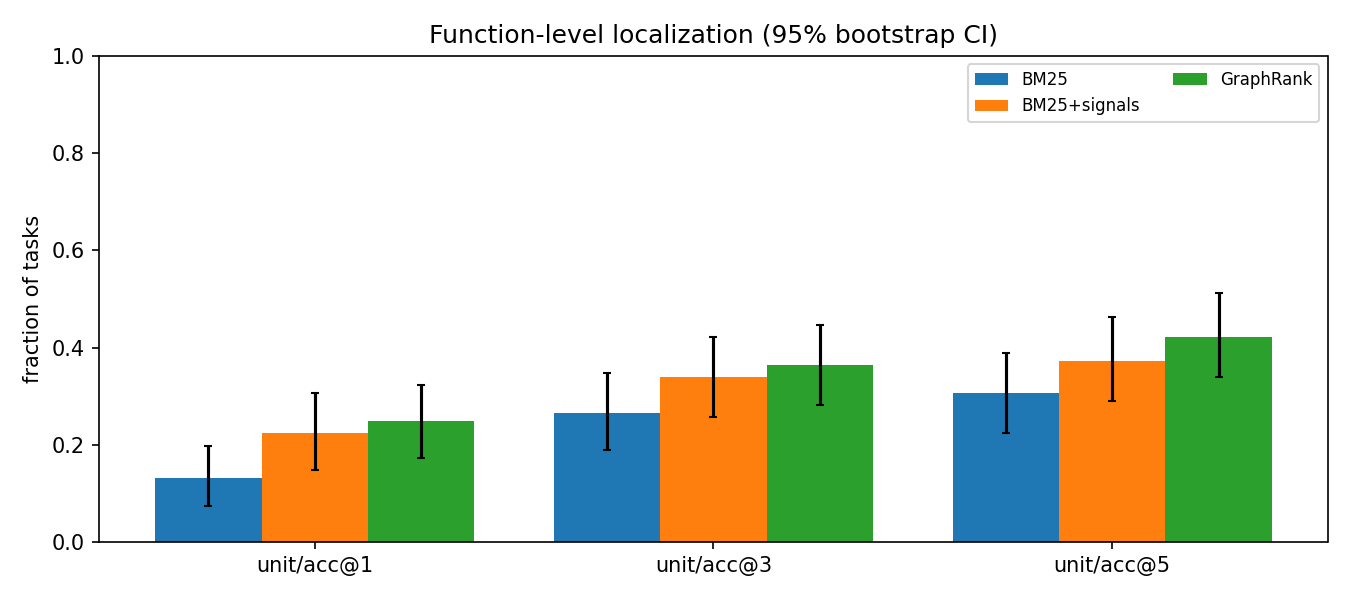

In [22]:
from IPython.display import Image, display

if len(AGG) >= 2:
    mets = ["unit/acc@1", "unit/acc@3", "unit/acc@5"]
    fig, ax = plt.subplots(figsize=(9, 4))
    w = 0.8 / len(AGG)
    for i, (name, a) in enumerate(AGG.items()):
        xs = [j + i * w for j in range(len(mets))]
        ys = [a[m]["mean"] for m in mets]
        err = [
            [a[m]["mean"] - a[m]["ci_lo"] for m in mets],
            [a[m]["ci_hi"] - a[m]["mean"] for m in mets],
        ]
        ax.bar(xs, ys, w, yerr=err, capsize=2, label=name)
    ax.set_xticks([j + 0.4 - w / 2 for j in range(len(mets))])
    ax.set_xticklabels(mets)
    ax.set_ylabel("fraction of tasks")
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8, ncol=2)
    ax.set_title("Function-level localization (95% bootstrap CI)")
    fig.tight_layout()
    fig.savefig(CFG["OUT"] / "unit_acc.png", dpi=150)
    plt.close(fig)  # Close the plot to free memory

    # Display the saved figure in the notebook output
    display(Image(filename=str(CFG["OUT"] / "unit_acc.png")))

In [23]:
# Paired comparisons with Holm correction.
pairs=[("BM25","BM25+signals"),("BM25+signals","GraphRank"),("BM25","GraphRank"),("LLM-A","LLM-S"),("LLM-A","LLM-D"),("LLM-S","LLM-D")]
out=[]
for a,b in pairs:
    if a not in RESULTS or b not in RESULTS: continue
    for m in ["unit/acc@1","unit/acc@5","unit/mrr","file/acc@1"]:
        try:
            r=paired_bootstrap(RESULTS[a],RESULTS[b],m)
            out.append({"comparison":f"{b} - {a}","metric":m,"n":r["n"],"diff":r["mean_diff"],"ci_lo":r["ci_lo"],"ci_hi":r["ci_hi"],"p":r["p_value"]})
        except Exception: pass
cmp_df=pd.DataFrame(out)
if len(cmp_df):
    order=cmp_df["p"].argsort().tolist(); m=len(cmp_df); adj=[None]*m; running=0.0
    for rank,pos in enumerate(order):
        running=max(running,min(1.0,(m-rank)*float(cmp_df.iloc[pos]["p"]))); adj[pos]=running
    cmp_df["p_holm"]=adj; cmp_df["significant_0.05"]=cmp_df.p_holm<0.05
    cmp_df["ci"]=cmp_df.apply(lambda r:f"[{r.ci_lo:.3f},{r.ci_hi:.3f}]",axis=1)
    display(cmp_df[["comparison","metric","n","diff","ci","p","p_holm","significant_0.05"]])
    cmp_df.to_csv(CFG["OUT"]/"paired_comparisons_holm.csv",index=False)
else: print("No paired comparisons available.")
        

,comparison,metric,n,diff,ci,p,p_holm,significant_0.05
0,BM25+signals - BM25,unit/acc@1,121,0.090909,"[0.041,0.149]",0.0000,0.0000,True
1,BM25+signals - BM25,unit/acc@5,121,0.066116,"[0.025,0.116]",0.0000,0.0000,True
2,BM25+signals - BM25,unit/mrr,121,0.080362,"[0.039,0.126]",0.0000,0.0000,True
3,BM25+signals - BM25,file/acc@1,128,0.070312,"[0.023,0.125]",0.0024,0.0120,True
4,GraphRank - BM25+signals,unit/acc@1,121,0.024793,"[-0.008,0.066]",0.2444,0.2444,False
5,GraphRank - BM25+signals,unit/acc@5,121,0.049587,"[0.008,0.099]",0.0288,0.0864,False
6,GraphRank - BM25+signals,unit/mrr,121,0.036239,"[0.011,0.066]",0.0044,0.0176,True
7,GraphRank - BM25+signals,file/acc@1,128,0.054688,"[0.008,0.109]",0.0388,0.0864,False
8,GraphRank - BM25,unit/acc@1,121,0.115702,"[0.050,0.182]",0.0004,0.0024,True
9,GraphRank - BM25,unit/acc@5,121,0.115702,"[0.066,0.174]",0.0000,0.0000,True


## 7. Save everything (measured values only)

In [24]:
def _ver(m):
    try:
        return __import__(m).__version__
    except Exception:
        return None

manifest = dict(
    study_design="Q1-upgraded",
    n_tasks=len(tasks), instance_ids=[t["instance_id"] for t in tasks], has_gold=HAS_GOLD,
    systems=list(RESULTS), phase2_ran=LLM_READY, phase2_skip_reason=why_skipped,
    config={k: (str(v) if isinstance(v, Path) else v) for k, v in CFG.items()},
    model_path=mp if LLM_READY else None, gpus=n_gpu,
    gpu_name=(__import__("torch").cuda.get_device_name(0) if n_gpu else None) if "torch" in sys.modules else None,
    versions=dict(python=platform.python_version(), vllm=_ver("vllm"), torch=_ver("torch")),
    toolkit_sha256=hashlib.sha256(tk.read_bytes()).hexdigest() if tk.is_file() else None,
    timestamp=time.strftime("%Y-%m-%d %H:%M:%S"),
    seed=CFG["RANDOM_SEED"], selected_alpha=globals().get("selected_alpha"),
)
(CFG["OUT"] / "run_manifest.json").write_text(json.dumps(manifest, indent=1))
(CFG["OUT"] / "per_instance.json").write_text(json.dumps(RESULTS))
(CFG["OUT"] / "aggregate.json").write_text(json.dumps(AGG, indent=1))
stats_df.to_csv(CFG["OUT"] / "graph_stats.csv", index=False)
print("saved to", CFG["OUT"], "->", sorted(p.name for p in CFG["OUT"].iterdir()))

if CFG["PACK"]:
    zp = CFG["OUT"].parent / "ggil_bundle.zip"
    with zipfile.ZipFile(zp, "w", zipfile.ZIP_DEFLATED) as z:
        for p in Path(pkg_root / "ggil").rglob("*.py"):
            z.write(p, Path("ggil") / p.relative_to(pkg_root / "ggil"))
        for p in CFG["OUT"].iterdir():
            z.write(p, Path("results") / p.name)
    print("bundle:", zp, "(NOTE: this is not an official competition submission; follow the competition's required layout)")

saved to /kaggle/working/ggil_results_q1 -> ['aggregate.json', 'graph_relation_ablation.csv', 'graph_stats.csv', 'paired_comparisons_holm.csv', 'per_instance.json', 'propagation_weight_sensitivity.csv', 'repository_scale_analysis.csv', 'results_table.csv', 'run_manifest.json', 'snapshot_sensitivity.csv', 'task_level_graph_gains.csv', 'unit_acc.png']


# Part B — BlastRadius: graph-based change-impact analysis (new task + benchmark)

Part A asked **where** a fix belongs. Part B asks the question an engineer asks next: **what does this change touch, and which tests must run?**

**Task.** Given a pre-fix repository snapshot and a patch, rank the repository's test files (and test functions) by how likely they are to be affected.

**Ground truth, Tier A (runs on your data now).** The task file has `patch` and `test_patch` but **no fail-to-pass lists**, so ground truth is *the existing test files and test functions the developer's own fix modified*. This is a proxy, not an execution-verified label. It under-counts impacted tests (developers do not touch every affected test) and tests that were *newly added* by `test_patch` cannot exist in the pre-fix snapshot, so they are excluded and counted separately.

**Ground truth, Tier B (optional, execution-verified).** Mutate code in the changed files, run the repository's own test suite, and label each mutant with the test files whose outcome changed. It needs each repository's test dependencies installed and a suite that finishes within a timeout. Mutants whose run times out are dropped, never partially labelled. Off by default (`BR["RUN_TIER_B"]`).

**Method.** A repaired multi-relation code graph (calls, inheritance, decorators, imports, name references, member-of, including star-imports and `__all__`) is built in one AST pass per file. Changed symbols from the patch become seeds, and impact is propagated backwards along dependency edges with per-hop decay `gamma`. Test files are scored by their best-reaching symbol, with a name-link signal and a BM25 tie-break.

| RQ | Question |
|---|---|
| RQ7 | Does reverse-reachability over the graph beat random, path/name, and BM25 baselines at ranking developer-updated tests? |
| RQ8 | Which relations matter (calls vs imports vs inheritance/decorators vs heuristic name-based edges)? |
| RQ9 | How sensitive is ranking to decay `gamma` (selected on dev tasks, frozen on held-out)? |
| RQ10 | Does a small-LLM reranker add value beyond the graph? (needs Phase 2) |
| RQ11 | Do conclusions hold on execution-verified Tier B labels? (optional) |

**No result is simulated or back-filled.** Anything that cannot run is reported as unavailable with the reason.

In [25]:
# ===== Part B configuration =====
import ast, re, math, heapq, shutil, tempfile, warnings, shlex, subprocess, random, difflib, hashlib
from collections import defaultdict, Counter
BR = dict(
    GAMMA=0.70, MAX_HOPS=4, GAMMA_GRID=[0.3, 0.5, 0.7, 0.85, 0.95], TOPK=[1, 3, 5, 10],
    # edge weight per relation (impact survives a hop of this type with this factor, before gamma)
    EDGE_W={"call": 1.0, "inherit": 0.9, "decorator": 0.8, "ref": 0.5, "import": 0.6, "member": 0.5,
            "call_heur": 0.5, "ref_heur": 0.3},
    HEUR_MAX_CANDIDATES=3,     # name-based fallback edges only when a method/function name is (near-)unique
    NAME_LINK_W=0.8, MAX_PY_BYTES=400_000,
    PREP_MAX_MINUTES=90,
    RUN_RERANK=True, N_RERANK=15,
    RUN_TIER_B=False, TIER_B_TASKS=10, TIER_B_MUTANTS_PER_TASK=8, TIER_B_TIMEOUT=180,
    OUT=CFG["OUT"] / "blastradius")
BR["OUT"].mkdir(parents=True, exist_ok=True)
print({k: (str(v) if isinstance(v, Path) else v) for k, v in BR.items() if k != "EDGE_W"})

{'GAMMA': 0.7, 'MAX_HOPS': 4, 'GAMMA_GRID': [0.3, 0.5, 0.7, 0.85, 0.95], 'TOPK': [1, 3, 5, 10], 'HEUR_MAX_CANDIDATES': 3, 'NAME_LINK_W': 0.8, 'MAX_PY_BYTES': 400000, 'PREP_MAX_MINUTES': 90, 'RUN_RERANK': True, 'N_RERANK': 15, 'RUN_TIER_B': False, 'TIER_B_TASKS': 10, 'TIER_B_MUTANTS_PER_TASK': 8, 'TIER_B_TIMEOUT': 180, 'OUT': '/kaggle/working/ggil_results_q1/blastradius'}


In [26]:
# ===== BlastRadius core: repaired code graph, patch->seeds, reverse-reachability ranking, metrics =====
import ast, re, math, heapq, shutil, tempfile, warnings, shlex, json, sys, os, subprocess, time
from collections import defaultdict, Counter
from pathlib import Path
import numpy as np

SKIP_DIRS = {".git", ".tox", ".venv", "venv", "env", "node_modules", "build", "dist", "__pycache__",
             "site-packages", ".eggs", ".mypy_cache", ".pytest_cache"}

def list_py(root):
    root = Path(root); out = []
    for dp, dns, fns in os.walk(root):
        dns[:] = [d for d in dns if d not in SKIP_DIRS and not d.endswith(".egg-info")]
        for f in fns:
            if f.endswith(".py"):
                p = Path(dp) / f
                try:
                    if p.stat().st_size <= BR["MAX_PY_BYTES"]:
                        out.append(p.relative_to(root).as_posix())
                except OSError:
                    pass
    return sorted(out)

def is_test_path(p):
    parts = p.lower().split("/"); name = parts[-1]
    return (name.startswith("test_") or name.endswith("_test.py")
            or any(d in ("tests", "test", "testing") for d in parts[:-1]))

# ---------------------------------------------------------------- diff parsing
_HUNK = re.compile(r"^@@ -(\d+)(?:,(\d+))? \+(\d+)(?:,(\d+))? @@")

def parse_diff(patch):
    """-> {old_path: dict(is_new, is_deleted, lines=[('rem'|'ins', old_line, indent)], text=[changed line texts])}
    'ins' lines are anchored at the old line they precede (old_line), with the indent of the added text."""
    files, cur, old_ln, pend = {}, None, None, None
    L = (patch or "").splitlines(); i = 0
    while i < len(L):
        line = L[i]
        if line.startswith("--- ") and i + 1 < len(L) and L[i + 1].startswith("+++ "):
            a = line[4:].split("\t")[0].strip(); b = L[i + 1][4:].split("\t")[0].strip()
            old = None if a == "/dev/null" else (a[2:] if a.startswith("a/") else a)
            new = None if b == "/dev/null" else (b[2:] if b.startswith("b/") else b)
            path = old or new
            cur = files.setdefault(path, dict(is_new=old is None, is_deleted=new is None, lines=[], text=[]))
            old_ln = None; i += 2; continue
        m = _HUNK.match(line)
        if m and cur is not None:
            old_ln = int(m.group(1)); i += 1; continue
        if cur is not None and old_ln is not None:
            if line.startswith("-"):
                cur["lines"].append(("rem", old_ln, 0)); cur["text"].append(line[1:]); old_ln += 1
            elif line.startswith("+"):
                body = line[1:]; ind = len(body) - len(body.lstrip(" \t")) if body.strip() else 1
                cur["lines"].append(("ins", old_ln, ind)); cur["text"].append(body)
            elif line.startswith("\\"):
                pass
            elif line.startswith("diff --git"):
                cur = None; old_ln = None
            else:
                old_ln += 1
        i += 1
    return files

# ---------------------------------------------------------------- AST scan (one parse per file)
def _chain(node):
    if isinstance(node, ast.Name): return (node.id,)
    if isinstance(node, ast.Attribute):
        c = _chain(node.value)
        return c + (node.attr,) if c else None
    return None

class _Scan(ast.NodeVisitor):
    def __init__(self, f):
        self.f = f; self.stack = [f]; self.qual = []; self.cls = [None]
        self.defs = []; self.refs = defaultdict(set); self.imports = []; self.all = None
    def _add(self, node, kind):
        c = _chain(node)
        if c:
            self.refs[self.stack[-1]].add((kind, c)); return
        if isinstance(node, ast.Attribute):
            self.refs[self.stack[-1]].add((kind, ("?", node.attr))); self.visit(node.value)
        else:
            self.visit(node)
    def visit_Name(self, node):
        if isinstance(node.ctx, ast.Load): self.refs[self.stack[-1]].add(("ref", (node.id,)))
    def visit_Attribute(self, node):
        if isinstance(node.ctx, ast.Load): self._add(node, "ref")
        else: self.visit(node.value)
    def visit_Call(self, node):
        self._add(node.func, "call")
        for a in node.args: self.visit(a)
        for k in node.keywords: self.visit(k.value)
    def _grab_all(self, node, value):
        if len(self.stack) == 1 and isinstance(value, (ast.List, ast.Tuple)):
            names = [e.value for e in value.elts if isinstance(e, ast.Constant) and isinstance(e.value, str)]
            self.all = (self.all or []) + names
    def visit_Assign(self, node):
        if any(isinstance(t, ast.Name) and t.id == "__all__" for t in node.targets): self._grab_all(node, node.value)
        self.generic_visit(node)
    def visit_AugAssign(self, node):
        if isinstance(node.target, ast.Name) and node.target.id == "__all__": self._grab_all(node, node.value)
        self.generic_visit(node)
    def visit_Import(self, node):
        for a in node.names: self.imports.append(("import", a.name, a.asname, 0))
    def visit_ImportFrom(self, node):
        self.imports.append(("from", node.module or "", [(a.name, a.asname) for a in node.names], node.level or 0))
    def _def(self, node, kind):
        q = ".".join(self.qual + [node.name]); sid = f"{self.f}::{q}"
        start = min([node.lineno] + [d.lineno for d in node.decorator_list])
        end = getattr(node, "end_lineno", None) or node.lineno
        self.defs.append((sid, q, kind, start, end, self.stack[-1], self.cls[-1]))
        self.stack.append(sid); self.qual.append(node.name)
        for d in node.decorator_list: self._add(d.func if isinstance(d, ast.Call) else d, "decorator")
        if kind == "class":
            for b in node.bases: self._add(b, "inherit")
            self.cls.append(sid)
        else:
            a = node.args
            for d in list(a.defaults) + [x for x in a.kw_defaults if x is not None]: self.visit(d)
        for st in node.body: self.visit(st)
        if kind == "class": self.cls.pop()
        self.qual.pop(); self.stack.pop()
    def visit_FunctionDef(self, node): self._def(node, "func")
    def visit_AsyncFunctionDef(self, node): self._def(node, "func")
    def visit_ClassDef(self, node): self._def(node, "class")

# ---------------------------------------------------------------- repaired graph
class RepoGraph:
    """Nodes: file paths and 'file::Qual.name' symbols. Edge u->v means 'u depends on v' (stored reversed in .rev[v]).
    Relations: call, inherit, decorator, ref, import, member (+ call_heur/ref_heur name-based fallbacks)."""
    def __init__(self, root):
        self.root = Path(root); self.files = list_py(self.root); self.fileset = set(self.files)
        self.nodes = set(self.files); self.defs = {}; self.parent = {}; self.cls_of = {}
        self.file_syms = defaultdict(list); self.toplevel = defaultdict(dict); self.by_name = defaultdict(list)
        self.test_files = set(); self.is_test_sym = set(); self.parse_errors = 0
        self.rev = defaultdict(list); self._seen = set(); self.stars = defaultdict(list); self._memo = {}; self.all_names = {}
        scans = {}
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            for f in self.files:
                try:
                    tree = ast.parse((self.root / f).read_text(encoding="utf-8", errors="ignore"))
                    sc = _Scan(f); sc.visit(tree); scans[f] = sc
                except (SyntaxError, ValueError, RecursionError, MemoryError):
                    self.parse_errors += 1
        for f, sc in scans.items():
            self.all_names[f] = set(sc.all) if sc.all is not None else None
            for sid, q, kind, start, end, parent, cls in sc.defs:
                self.defs[sid] = (f, q, kind, start, end); self.nodes.add(sid); self.parent[sid] = parent
                self.file_syms[f].append((start, end, sid)); self.cls_of[sid] = cls
                last = q.rsplit(".", 1)[-1]; self.by_name[last].append(sid)
                if "." not in q: self.toplevel[f][q] = sid
                if kind == "func" and last.startswith("test") and is_test_path(f):
                    self.is_test_sym.add(sid); self.test_files.add(f)
        for f, sc in scans.items():
            for sid, *_rest in sc.defs: self._edge(sid, self.parent[sid], "member")
        self.modmap = defaultdict(list)
        for p in self.files:
            parts = p[:-3].split("/")
            if parts[-1] == "__init__": parts = parts[:-1]
            for i in range(len(parts)): self.modmap[".".join(parts[i:])].append(p)
        self.imports = defaultdict(dict)
        for f, sc in scans.items(): self._build_imports(f, sc)
        for f in scans:
            for loc, ent in self.imports[f].items():
                if ent[0] == "mod" and ent[1]: self._edge(f, ent[1], "import")
                elif ent[0] == "sym" and ent[1]: self._edge(f, self._lookup(ent[1], ent[2], 0) or ent[1], "import")
        for f, sc in scans.items():
            tl, im = self.toplevel[f], self.imports[f]
            for src, refs in sc.refs.items():
                for kind, parts in refs:
                    if parts[0] not in ("?", "self", "cls") and parts[0] not in tl and parts[0] not in im: continue
                    for tgt, k in self._resolve(f, src, kind, parts): self._edge(src, tgt, k)
        self._seen = None; self._memo = {}

    def _edge(self, u, v, t):
        if u == v: return
        k = (u, v, t)
        if k in self._seen: return
        self._seen.add(k); self.rev[v].append((u, t, BR["EDGE_W"][t]))

    def _mod_file(self, name, frm):
        c = self.modmap.get(name)
        if not c: return None
        if len(c) == 1: return c[0]
        d = frm.split("/")
        def common(p):
            n = 0
            for a, b in zip(d, p.split("/")):
                if a != b: break
                n += 1
            return n
        return max(c, key=lambda p: (common(p), -len(p)))

    def _rel_file(self, frm, level, module):
        base = frm.split("/")[:-1]
        if level > 1: base = base[:-(level - 1)] if len(base) >= level - 1 else []
        parts = base + [x for x in (module or "").split(".") if x]
        for c in ("/".join(parts) + ".py", "/".join(parts + ["__init__"]) + ".py"):
            c = c.lstrip("/")
            if c in self.fileset: return c
        return None

    def _build_imports(self, f, sc):
        tbl = self.imports[f]
        for rec in sc.imports:
            if rec[0] == "import":
                _, name, asname, _l = rec
                if asname: tbl[asname] = ("mod", self._mod_file(name, f), name)
                else:
                    top = name.split(".")[0]; tbl.setdefault(top, ("mod", self._mod_file(top, f), top))
            else:
                _, module, names, level = rec
                F = self._rel_file(f, level, module) if level else self._mod_file(module, f)
                for n, asn in names:
                    if n == "*":
                        if F and F != f: self.stars[f].append(F)
                        continue
                    loc = asn or n; full = (module + "." + n) if module else n
                    sub = self._rel_file(f, level, full) if level else self._mod_file(full, f)
                    if sub and sub != F: tbl[loc] = ("mod", sub, full)
                    elif F: tbl[loc] = ("sym", F, n)

    def _lookup(self, F, name, depth=0):
        key = (F, name)
        if key in self._memo: return self._memo[key]
        self._memo[key] = None                      # breaks import cycles
        res = self.toplevel[F].get(name)
        if res is None and depth < 8:
            ent = self.imports[F].get(name)
            if ent and ent[1]:
                res = self._lookup(ent[1], ent[2], depth + 1) if ent[0] == "sym" else ent[1]
            if res is None:
                for S in self.stars.get(F, ()):
                    al = self.all_names.get(S)
                    if (name not in al) if al is not None else name.startswith("_"): continue
                    res = self._lookup(S, name, depth + 1)
                    if res: break
        self._memo[key] = res
        return res

    def _heur(self, name, kind):
        c = self.by_name.get(name, [])
        if 0 < len(c) <= BR["HEUR_MAX_CANDIDATES"]:
            return [(x, "call_heur" if kind == "call" else "ref_heur") for x in c]
        return []

    def _resolve(self, f, src, kind, parts):
        first = parts[0]
        if first == "?": return self._heur(parts[1], kind)
        if first in ("self", "cls"):
            if len(parts) < 2: return []
            cls = self.cls_of.get(src) if src != f else None
            if cls:
                sid = f"{cls}.{parts[1]}"
                if sid in self.defs: return [(sid, kind)]
            return self._heur(parts[1], kind)
        if first in self.toplevel[f]:
            s = self.toplevel[f][first]; rest = parts[1:]
            if rest and f"{s}.{rest[0]}" in self.defs: s = f"{s}.{rest[0]}"
            return [(s, kind)]
        ent = self.imports[f].get(first)
        if not ent or not ent[1]: return []
        if ent[0] == "sym":
            t = self._lookup(ent[1], ent[2], 0)
            if t is None: return [(ent[1], kind)]
            if t in self.defs:
                rest = parts[1:]
                if rest and f"{t}.{rest[0]}" in self.defs: t = f"{t}.{rest[0]}"
            return [(t, kind)]
        fl, rest = ent[1], parts[1:]
        for j in range(len(parts) - 1, 0, -1):
            dotted = ".".join([ent[2]] + list(parts[1:j]))
            cand = self._mod_file(dotted, f)
            if cand: fl, rest = cand, parts[j:]; break
        if not rest: return [(fl, kind)]
        t = self._lookup(fl, rest[0], 0)
        if t is None: return [(fl, kind)]
        if t in self.defs and len(rest) > 1 and f"{t}.{rest[1]}" in self.defs: t = f"{t}.{rest[1]}"
        return [(t, kind)]

    def symbol_at(self, f, line):
        best = None
        for s, e, sid in self.file_syms.get(f, ()):
            if s <= line <= e and (best is None or (e - s) < (best[1] - best[0])): best = (s, e, sid)
        return best[2] if best else None

    def _ancestors(self, sid):
        out = []
        while sid in self.defs: out.append(sid); sid = self.parent[sid]
        return out

    def ins_symbol(self, f, pos, indent):
        c1, c2 = self.symbol_at(f, pos - 1), self.symbol_at(f, pos)
        if c1 == c2: return c1 if indent > 0 else None
        if c1 and c2:
            a2 = set(self._ancestors(c2))
            for a in self._ancestors(c1):
                if a in a2: return a
            return None
        return (c1 or c2) if indent > 0 else None

    def propagate(self, seeds, gamma, max_hops, allowed=None):
        score, hops, h = {}, {}, []
        for s, w in seeds.items():
            if s in self.nodes: score[s] = w; hops[s] = 0; heapq.heappush(h, (-w, s))
        while h:
            ns, v = heapq.heappop(h); s = -ns
            if s < score.get(v, 0.0) - 1e-12 or hops[v] >= max_hops: continue
            for u, t, w in self.rev.get(v, ()):
                if allowed is not None and t not in allowed: continue
                s2 = s * w * gamma
                if s2 > score.get(u, 0.0):
                    score[u] = s2; hops[u] = hops[v] + 1; heapq.heappush(h, (-s2, u))
        return score

    def test_file_scores(self, score):
        out = {}
        for f in self.test_files:
            vals = [score.get(f, 0.0)] + [score.get(sid, 0.0) for _, _, sid in self.file_syms[f]]
            out[f] = (max(vals), sum(vals))
        return out

    def stats(self):
        c = Counter(t for lst in self.rev.values() for _, t, _ in lst)
        return dict(files=len(self.files), symbols=len(self.defs), test_files=len(self.test_files),
                    parse_errors=self.parse_errors, edges=dict(c))

# ---------------------------------------------------------------- patch -> seeds
def changed_from_patch(rg, patch, include_tests=False):
    seeds, cfiles, text = {}, set(), []
    for path, info in parse_diff(patch).items():
        if not path.endswith(".py") or (is_test_path(path) and not include_tests): continue
        cfiles.add(path); text += info["text"]
        if path not in rg.nodes or info["is_new"]: continue
        for kind, ln, ind in info["lines"]:
            sid = rg.symbol_at(path, ln) if kind == "rem" else rg.ins_symbol(path, ln, ind)
            seeds[sid or path] = 1.0
    return seeds, cfiles, "\n".join(text)

# ---------------------------------------------------------------- lexical + name signals
_STOP = set("self cls def return import from none true false and the for not with else elif class pass test tests assert".split())
def _toks(s):
    out = []
    for w in re.findall(r"[A-Za-z_][A-Za-z0-9_]*", s or ""):
        for p in re.sub(r"([a-z0-9])([A-Z])", r"\1 \2", w).replace("_", " ").lower().split():
            if len(p) > 1 and p not in _STOP: out.append(p)
    return out

def bm25_scores(root, files, query, k1=1.5, b=0.75):
    docs, df = {}, Counter()
    for f in files:
        try: t = _toks((Path(root) / f).read_text(encoding="utf-8", errors="ignore"))
        except OSError: t = []
        c = Counter(t); docs[f] = (c, len(t)); df.update(c.keys())
    N = max(len(files), 1); avg = (sum(l for _, l in docs.values()) / N) or 1.0
    q = Counter(query); sc = {}
    for f, (c, l) in docs.items():
        s = 0.0
        for w, qc in q.items():
            if w in c:
                idf = math.log(1 + (N - df[w] + 0.5) / (df[w] + 0.5))
                s += idf * c[w] * (k1 + 1) / (c[w] + k1 * (1 - b + b * l / avg))
        sc[f] = s
    return sc

def name_link(test_path, cfiles):
    tn = re.sub(r"^test_?|_?tests?$", "", Path(test_path).stem.lower()); best = 0.0
    tdirs = set(Path(test_path).parent.parts) - {"src", "tests", "test", "testing", ".", ""}
    for c in cfiles:
        cn = Path(c).stem.lower()
        if cn == "__init__": cn = Path(c).parent.name.lower()
        if tn and tn == cn: best = max(best, 1.0)
        elif tn and cn and min(len(tn), len(cn)) >= 4 and (tn in cn or cn in tn): best = max(best, 0.6)
        elif tdirs & (set(Path(c).parent.parts) - {"src", ".", ""}): best = max(best, 0.3)
    return best

def make_prep(rg, root, seeds, cfiles, ptext):
    cands = sorted(rg.test_files)
    names = [s.split("::")[-1].split(".")[-1] for s in seeds] + [Path(c).stem for c in cfiles]
    query = _toks(" ".join(names)) * 3 + _toks(ptext)
    bm = bm25_scores(root, cands, query) if cands and query else {f: 0.0 for f in cands}
    mx = max(bm.values()) if bm else 0.0
    return dict(rg=rg, seeds=seeds, cfiles=cfiles, cands=cands,
                name={f: name_link(f, cfiles) for f in cands},
                bm25n={f: (bm[f] / mx if mx > 0 else 0.0) for f in cands})

# ---------------------------------------------------------------- ranking
def rank_tests(prep, gamma=None, allowed=None, use_graph=True, use_name=True, use_bm25=True, max_hops=None, with_scores=False):
    rg = prep["rg"]; gamma = BR["GAMMA"] if gamma is None else gamma
    sc = rg.propagate(prep["seeds"], gamma, max_hops or BR["MAX_HOPS"], allowed) if use_graph else {}
    tf = rg.test_file_scores(sc) if use_graph else {}
    rows = []
    for f in prep["cands"]:
        g, gs = tf.get(f, (0.0, 0.0))
        primary = max(g, BR["NAME_LINK_W"] * prep["name"][f] if use_name else 0.0)
        tie = 0.01 * math.log1p(gs) + (0.001 * prep["bm25n"][f] if use_bm25 else 0.0)
        rows.append((-(primary + tie), f, primary))
    rows.sort()
    return [(f, p) for _, f, p in rows] if with_scores else [f for _, f, _ in rows]

def rank_test_funcs(prep, gamma=None, allowed=None, use_graph=True, use_name=True, use_bm25=True):
    rg = prep["rg"]; gamma = BR["GAMMA"] if gamma is None else gamma
    sc = rg.propagate(prep["seeds"], gamma, BR["MAX_HOPS"], allowed) if use_graph else {}
    rows = []
    for sid in rg.is_test_sym:
        f = rg.defs[sid][0]
        primary = max(sc.get(sid, 0.0), BR["NAME_LINK_W"] * prep["name"].get(f, 0.0) if use_name else 0.0)
        rows.append((-(primary + (0.001 * prep["bm25n"].get(f, 0.0) if use_bm25 else 0.0)), sid))
    rows.sort()
    return [s for _, s in rows]

# ---------------------------------------------------------------- Tier A ground truth (developer-updated tests)
def gold_tests(rg, test_patch):
    files, funcs, new_files = set(), set(), 0
    for path, info in parse_diff(test_patch).items():
        if not path.endswith(".py"): continue
        if info["is_new"]: new_files += 1; continue
        if path not in rg.test_files: continue
        files.add(path)
        for kind, ln, ind in info["lines"]:
            sid = rg.symbol_at(path, ln) if kind == "rem" else rg.ins_symbol(path, ln, ind)
            if sid in rg.is_test_sym: funcs.add(sid)
    return files, funcs, new_files

# ---------------------------------------------------------------- metrics + statistics
def rank_metrics(ranked, gold):
    N = len(ranked); pos = {p: i + 1 for i, p in enumerate(ranked)}
    gp = sorted(pos[g] for g in gold if g in pos); out = {}
    if not gp: return out
    for k in BR["TOPK"]:
        out[f"hit@{k}"] = float(gp[0] <= k); out[f"recall@{k}"] = sum(p <= k for p in gp) / len(gold)
    out["mrr"] = 1.0 / gp[0]; out["cost@full"] = gp[-1] / N; out["n_cands"] = N; out["n_gold"] = len(gold)
    return out

def boot_ci(vals, n_boot, seed):
    v = np.asarray(vals, float)
    if len(v) == 0: return (float("nan"),) * 3
    rng = np.random.default_rng(seed); m = v[rng.integers(0, len(v), (n_boot, len(v)))].mean(1)
    return float(v.mean()), float(np.percentile(m, 2.5)), float(np.percentile(m, 97.5))

def paired_boot(a, b, n_boot, seed):
    d = np.asarray(b, float) - np.asarray(a, float); rng = np.random.default_rng(seed)
    m = d[rng.integers(0, len(d), (n_boot, len(d)))].mean(1)
    p = float(min(1.0, 2 * (min((m <= 0).sum(), (m >= 0).sum()) + 1) / (n_boot + 1)))
    return dict(n=len(d), diff=float(d.mean()), ci_lo=float(np.percentile(m, 2.5)), ci_hi=float(np.percentile(m, 97.5)), p=p)

def holm(ps):
    order = np.argsort(ps); m = len(ps); adj = [None] * m; run = 0.0
    for r, i in enumerate(order):
        run = max(run, min(1.0, (m - r) * ps[i])); adj[i] = run
    return adj

# ---------------------------------------------------------------- tool for the agent loop
def impact_check(repo_root, patch, k=5, gamma=None):
    """Return the k most-likely-affected test files for a patch. Build on the PRE-edit tree
    (the diff's old-side line numbers refer to it). Returns a ready-to-run pytest command."""
    rg = RepoGraph(repo_root); seeds, cfiles, ptext = changed_from_patch(rg, patch)
    prep = make_prep(rg, repo_root, seeds, cfiles, ptext)
    top = [f for f, p in rank_tests(prep, gamma=gamma, with_scores=True)[:k] if p > 0]
    return dict(changed=sorted(seeds), tests=top,
                command="python -m pytest -x -q " + " ".join(shlex.quote(t) for t in top) if top else "")

In [27]:
# ===== Self-test on a synthetic repository (runs without competition data; fails loudly if the core is broken) =====
_toy = Path(tempfile.mkdtemp(prefix="br_selftest_"))
_F = {
 "pkg/__init__.py": "from .core import compute, Base\n",
 "pkg/core.py": "import os\nfrom .util import helper, scale\n\nLIMIT = 10\n\nclass Base:\n    def run(self, x):\n        return self.step(x) + 1\n\n    def step(self, x):\n        return helper(x)\n\ndef compute(x):\n    if x > LIMIT:\n        return scale(x)\n    return helper(x) * 2\n\ndef unrelated():\n    return os.getcwd()\n",
 "pkg/util.py": "def helper(x):\n    y = x + 1\n    return y\n\ndef scale(x):\n    return x * 3\n",
 "pkg/sub/__init__.py": "",
 "pkg/sub/child.py": "import pkg.core\nfrom pkg.core import Base\n\nclass Child(Base):\n    def step(self, x):\n        return super().step(x) + pkg.core.compute(x)\n\ndef make():\n    return Child()\n",
 "pkg/other.py": "def lonely():\n    return 42\n",
 "tests/test_core.py": "from pkg import compute\n\ndef test_compute_small():\n    assert compute(1) == 4\n\ndef test_compute_big():\n    assert compute(20) == 60\n",
 "tests/test_child.py": "from pkg.sub.child import make\n\nclass TestChild:\n    def test_make(self):\n        assert make().run(1) is not None\n",
 "tests/test_other.py": "from pkg.other import lonely\n\ndef test_lonely():\n    assert lonely() == 42\n",
 "tests/test_misc.py": "def test_nothing_related():\n    assert True\n",
}
for _p, _c in _F.items():
    (_toy / _p).parent.mkdir(parents=True, exist_ok=True); (_toy / _p).write_text(_c)
def _udiff(path, old, new):
    return "".join(difflib.unified_diff([] if old is None else old.splitlines(True), new.splitlines(True),
                                        "/dev/null" if old is None else f"a/{path}", f"b/{path}"))
_rg = RepoGraph(_toy)
def _has(u, v, t): return any(x == u and tt == t for x, tt, _ in _rg.rev.get(v, ()))
assert _has("pkg/core.py::compute", "pkg/util.py::helper", "call")
assert _has("pkg/core.py::Base.run", "pkg/core.py::Base.step", "call"), "self.method resolution"
assert _has("pkg/sub/child.py::Child", "pkg/core.py::Base", "inherit"), "inheritance via from-import"
assert _has("pkg/sub/child.py::Child.step", "pkg/core.py::compute", "call"), "dotted module chain"
assert _has("tests/test_core.py::test_compute_small", "pkg/core.py::compute", "call"), "re-export through __init__"
_p_helper = _udiff("pkg/util.py", _F["pkg/util.py"], _F["pkg/util.py"].replace("y = x + 1", "y = x + 2"))
_p_insert = _udiff("pkg/core.py", _F["pkg/core.py"], _F["pkg/core.py"].replace("    def step(self, x):", "    def extra(self):\n        return 0\n\n    def step(self, x):"))
_p_const = _udiff("pkg/core.py", _F["pkg/core.py"], _F["pkg/core.py"].replace("LIMIT = 10", "LIMIT = 11"))
for _p, _want in [(_p_helper, {"pkg/util.py::helper"}), (_p_insert, {"pkg/core.py::Base"}), (_p_const, {"pkg/core.py"})]:
    assert set(changed_from_patch(_rg, _p)[0]) == _want, (_want, changed_from_patch(_rg, _p)[0])
_s, _c, _t = changed_from_patch(_rg, _p_helper); _prep = make_prep(_rg, _toy, _s, _c, _t)
_r = rank_tests(_prep)
assert _r[:2] == ["tests/test_core.py", "tests/test_child.py"] and _r.index("tests/test_other.py") > 1, _r
_tp = _udiff("tests/test_core.py", _F["tests/test_core.py"], _F["tests/test_core.py"] + "    assert compute(30) == 90\n") \
      + _udiff("tests/test_new.py", None, "def test_new():\n    pass\n")
_gf, _gfn, _nf = gold_tests(_rg, _tp)
assert _gf == {"tests/test_core.py"} and _gfn == {"tests/test_core.py::test_compute_big"} and _nf == 1, (_gf, _gfn, _nf)
assert impact_check(_toy, _p_helper, k=3)["tests"][0] == "tests/test_core.py"
print("BlastRadius self-test passed:", _rg.stats())
shutil.rmtree(_toy, ignore_errors=True)

BlastRadius self-test passed: {'files': 10, 'symbols': 17, 'test_files': 4, 'parse_errors': 0, 'edges': {'member': 17, 'import': 9, 'inherit': 1, 'call': 10, 'call_heur': 2}}


## B1. Build graphs, seeds and Tier A ground truth

For every task: build the repaired graph on the **pre-fix** snapshot, map the gold `patch` to changed symbols (seeds), and map `test_patch` to the existing test files and test functions it modified. Coverage is reported before any modelling: a task only enters evaluation if at least one developer-modified test file exists in the snapshot.

In [28]:
BR_PREP, BR_SKIP, t0 = {}, Counter(), time.time()
deadline = t0 + BR["PREP_MAX_MINUTES"] * 60
for t in tasks:
    iid = t["instance_id"]; tp = (t.get("raw") or {}).get("test_patch") or ""
    if not t.get("patch"): BR_SKIP["no_patch"] += 1; continue
    if time.time() > deadline: BR_SKIP["prep_time_budget"] += 1; continue
    try:
        rg = RepoGraph(t["repo_root"])
        seeds, cfiles, ptext = changed_from_patch(rg, t["patch"])
        gf, gfn, nf = gold_tests(rg, tp)
        prep = make_prep(rg, t["repo_root"], seeds, cfiles, ptext)
    except Exception as e:
        BR_SKIP[f"error:{type(e).__name__}"] += 1; continue
    prep.update(iid=iid, gold_files=gf, gold_funcs=gfn, new_test_files=nf, has_test_patch=bool(tp), patch=t["patch"][:3000])
    BR_PREP[iid] = prep
print(f"prepared {len(BR_PREP)}/{len(tasks)} tasks in {time.time() - t0:.0f}s | skipped: {dict(BR_SKIP)}")

rows = []
for iid, p in BR_PREP.items():
    st = p["rg"].stats()
    rows.append(dict(instance_id=iid, files=st["files"], symbols=st["symbols"], test_files=st["test_files"],
                     parse_errors=st["parse_errors"], seeds=len(p["seeds"]), seed_is_file_level=sum("::" not in s for s in p["seeds"]),
                     gold_test_files=len(p["gold_files"]), gold_test_funcs=len(p["gold_funcs"]), new_test_files=p["new_test_files"],
                     has_test_patch=p["has_test_patch"]))
br_stats = pd.DataFrame(rows)
BR_EVAL = [i for i, p in BR_PREP.items() if p["gold_files"] and p["seeds"]]
print(f"\nTier A coverage: tasks with a test_patch: {int(br_stats.has_test_patch.sum())}/{len(br_stats)} | "
      f"with >=1 developer-modified test file present in the snapshot: {int((br_stats.gold_test_files > 0).sum())} | "
      f"with a changed-symbol seed: {int((br_stats.seeds > 0).sum())} | EVALUABLE (both): {len(BR_EVAL)}")
print(f"tasks whose test_patch only adds NEW test files (not scoreable here): {int(((br_stats.gold_test_files == 0) & (br_stats.new_test_files > 0)).sum())}")
print(f"tasks with function-level gold (a modified existing test function): {int((br_stats.gold_test_funcs > 0).sum())}")
display(br_stats.describe().T[["mean", "min", "max"]].round(1))
assert BR_EVAL, ("No evaluable tasks. Check the coverage line above: Tier A needs a test_patch that modifies EXISTING test files "
                 "present in the pre-fix snapshot, and a patch that changes existing Python code.")
if len(BR_EVAL) < 30: print("WARNING: fewer than 30 evaluable tasks; treat all intervals below as indicative only.")
br_stats.to_csv(BR["OUT"] / "blastradius_task_stats.csv", index=False)

prepared 129/129 tasks in 119s | skipped: {}

Tier A coverage: tasks with a test_patch: 129/129 | with >=1 developer-modified test file present in the snapshot: 97 | with a changed-symbol seed: 128 | EVALUABLE (both): 97
tasks whose test_patch only adds NEW test files (not scoreable here): 0
tasks with function-level gold (a modified existing test function): 81


,mean,min,max
files,690.6,35.0,1279.0
symbols,3474.0,727.0,5845.0
test_files,233.7,8.0,495.0
parse_errors,0.0,0.0,0.0
seeds,5.2,0.0,161.0
seed_is_file_level,1.0,0.0,20.0
gold_test_files,1.7,0.0,29.0
gold_test_funcs,4.2,0.0,173.0
new_test_files,0.0,0.0,0.0


## B2. Baselines and ladder (RQ7)

| System | Signal |
|---|---|
| Random | seeded shuffle (expected value reference) |
| NameMatch | test-file name / directory proximity to changed files only |
| BM25 | lexical match of changed symbols, file stems and diff text against test-file text |
| Graph(calls) | reverse reachability over call edges only (comparable in schema to the released graph, which the data audit found to be calls-only) |
| Graph(all) | reverse reachability over all repaired relations |
| Graph+Name | graph score combined with name link (max) |
| **BlastRadius** | Graph+Name with BM25 as tie-break |

Metrics: `hit@k` (any gold test in top-k), `recall@k`, `mrr`, and `cost@full` (fraction of the suite you must run to cover **every** gold test; lower is better, ~0.5 is chance).

In [29]:
BR_SYSTEMS = {
    "Random": None,
    "NameMatch": dict(use_graph=False, use_name=True, use_bm25=False),
    "BM25": dict(use_graph=False, use_name=False, use_bm25=True),
    "Graph(calls)": dict(allowed={"call", "call_heur"}, use_name=False, use_bm25=False),
    "Graph(all)": dict(use_name=False, use_bm25=False),
    "Graph+Name": dict(use_bm25=False),
    "BlastRadius": dict(),
}
def br_rank(prep, spec, gamma=None):
    if spec is None:
        r = list(prep["cands"]); random.Random(f"{CFG['RANDOM_SEED']}:{prep['iid']}").shuffle(r); return r
    return rank_tests(prep, gamma=gamma, **spec)

BR_RES = {}      # system -> {iid: metrics}
for name, spec in BR_SYSTEMS.items():
    BR_RES[name] = {i: rank_metrics(br_rank(BR_PREP[i], spec), BR_PREP[i]["gold_files"]) for i in BR_EVAL}

SHOW_BR = ["hit@1", "hit@3", "hit@5", "recall@3", "recall@5", "recall@10", "mrr", "cost@full"]
def br_table(res, ids=None):
    out = []
    for name, d in res.items():
        ids_ = [i for i in (ids if ids is not None else d) if i in d and d[i]]
        if not ids_: continue
        row = {"system": name, "n": len(ids_)}
        for m in SHOW_BR:
            mean, lo, hi = boot_ci([d[i][m] for i in ids_], CFG["BOOTSTRAP"], CFG["RANDOM_SEED"])
            row[m] = f"{mean:.3f} [{lo:.2f},{hi:.2f}]"
        out.append(row)
    return pd.DataFrame(out).set_index("system") if out else pd.DataFrame()
br_main = br_table(BR_RES); display(br_main); br_main.to_csv(BR["OUT"] / "blastradius_results.csv")

,n,hit@1,hit@3,hit@5,recall@3,recall@5,recall@10,mrr,cost@full
system,,,,,,,,,
Random,97,"0.010 [0.00,0.03]","0.041 [0.01,0.08]","0.124 [0.06,0.20]","0.032 [0.00,0.07]","0.104 [0.05,0.17]","0.238 [0.16,0.32]","0.083 [0.06,0.11]","0.553 [0.49,0.61]"
NameMatch,97,"0.515 [0.41,0.61]","0.557 [0.45,0.65]","0.577 [0.47,0.67]","0.516 [0.42,0.61]","0.538 [0.44,0.63]","0.626 [0.53,0.72]","0.563 [0.47,0.65]","0.228 [0.17,0.29]"
BM25,97,"0.546 [0.45,0.64]","0.742 [0.66,0.82]","0.804 [0.72,0.88]","0.676 [0.59,0.76]","0.737 [0.65,0.82]","0.791 [0.71,0.86]","0.656 [0.58,0.73]","0.092 [0.07,0.12]"
Graph(calls),97,"0.309 [0.22,0.40]","0.361 [0.27,0.45]","0.392 [0.30,0.48]","0.324 [0.23,0.41]","0.359 [0.27,0.45]","0.404 [0.31,0.50]","0.366 [0.28,0.45]","0.358 [0.30,0.42]"
Graph(all),97,"0.423 [0.33,0.52]","0.536 [0.43,0.64]","0.598 [0.51,0.69]","0.459 [0.36,0.55]","0.530 [0.43,0.63]","0.562 [0.47,0.65]","0.498 [0.41,0.58]","0.257 [0.20,0.32]"
Graph+Name,97,"0.619 [0.52,0.71]","0.711 [0.62,0.79]","0.742 [0.65,0.82]","0.659 [0.57,0.75]","0.701 [0.61,0.79]","0.712 [0.62,0.79]","0.678 [0.59,0.76]","0.139 [0.10,0.19]"
BlastRadius,97,"0.649 [0.56,0.74]","0.753 [0.66,0.84]","0.784 [0.70,0.87]","0.701 [0.61,0.78]","0.748 [0.66,0.83]","0.764 [0.68,0.84]","0.714 [0.63,0.79]","0.114 [0.08,0.15]"


In [30]:
# Paired comparisons with Holm correction (RQ7). cost@full is lower-is-better, so its sign is flipped for readability.
pairs = [("Random", "BM25"), ("Random", "Graph(all)"), ("Random", "BlastRadius"), ("NameMatch", "BlastRadius"),
         ("BM25", "BlastRadius"), ("BM25", "Graph(all)"), ("Graph(calls)", "Graph(all)"), ("Graph(all)", "BlastRadius")]
rows = []
for a, b in pairs:
    for m in ["recall@3", "recall@5", "mrr", "cost@full"]:
        ids = [i for i in BR_EVAL if BR_RES[a].get(i) and BR_RES[b].get(i)]
        if len(ids) < 2: continue
        sgn = -1.0 if m == "cost@full" else 1.0
        r = paired_boot([sgn * BR_RES[a][i][m] for i in ids], [sgn * BR_RES[b][i][m] for i in ids], CFG["BOOTSTRAP"], CFG["RANDOM_SEED"])
        rows.append(dict(comparison=f"{b} - {a}", metric=m + (" (improvement=lower)" if m == "cost@full" else ""), **r))
br_cmp = pd.DataFrame(rows)
if len(br_cmp):
    br_cmp["p_holm"] = holm(br_cmp["p"].tolist()); br_cmp["significant_0.05"] = br_cmp.p_holm < 0.05
    br_cmp["ci"] = br_cmp.apply(lambda r: f"[{r.ci_lo:.3f},{r.ci_hi:.3f}]", axis=1)
    display(br_cmp[["comparison", "metric", "n", "diff", "ci", "p", "p_holm", "significant_0.05"]])
    br_cmp.to_csv(BR["OUT"] / "blastradius_paired_holm.csv", index=False)

,comparison,metric,n,diff,ci,p,p_holm,significant_0.05
0,BM25 - Random,recall@3,97,0.643775,"[0.551,0.732]",0.000400,0.012797,True
1,BM25 - Random,recall@5,97,0.632765,"[0.543,0.723]",0.000400,0.012797,True
2,BM25 - Random,mrr,97,0.573526,"[0.493,0.654]",0.000400,0.012797,True
3,BM25 - Random,cost@full (improvement=lower),97,0.461098,"[0.399,0.520]",0.000400,0.012797,True
4,Graph(all) - Random,recall@3,97,0.427177,"[0.327,0.524]",0.000400,0.012797,True
5,Graph(all) - Random,recall@5,97,0.425918,"[0.323,0.526]",0.000400,0.012797,True
6,Graph(all) - Random,mrr,97,0.415242,"[0.327,0.501]",0.000400,0.012797,True
7,Graph(all) - Random,cost@full (improvement=lower),97,0.296135,"[0.222,0.371]",0.000400,0.012797,True
8,BlastRadius - Random,recall@3,97,0.668740,"[0.575,0.758]",0.000400,0.012797,True
9,BlastRadius - Random,recall@5,97,0.643378,"[0.551,0.737]",0.000400,0.012797,True


## B3. Decay sensitivity with a frozen held-out choice (RQ9)

Same protocol as 4B: `gamma` is selected on the deterministic *dev* split by `recall@3` (MRR as tie-break), frozen, then evaluated on the *test* split. The default `0.70` is reported as a non-tuned reference.

In [31]:
_split = globals().get("split_label")
if _split is None:
    def _split(iid):
        x = int(hashlib.sha256((iid + "::" + str(CFG["RANDOM_SEED"])).encode()).hexdigest()[:8], 16) / 0xFFFFFFFF * 100
        return "dev" if x < 20 else "test"
br_dev = [i for i in BR_EVAL if _split(i) == "dev"]; br_test = [i for i in BR_EVAL if _split(i) == "test"]

def eval_cfg(ids, spec=None, gamma=None):
    spec = {} if spec is None else spec
    rows = [rank_metrics(rank_tests(BR_PREP[i], gamma=gamma, **spec), BR_PREP[i]["gold_files"]) for i in ids]
    return rows
g_rows = []
for g in BR["GAMMA_GRID"]:
    rr = eval_cfg(br_dev, gamma=g)
    if rr: g_rows.append(dict(gamma=g, n=len(rr), dev_recall3=float(np.mean([r["recall@3"] for r in rr])), dev_mrr=float(np.mean([r["mrr"] for r in rr]))))
br_gamma = pd.DataFrame(g_rows); display(br_gamma)
BR_GAMMA = float(br_gamma.sort_values(["dev_recall3", "dev_mrr"], ascending=False).iloc[0]["gamma"]) if len(br_gamma) else BR["GAMMA"]
print("dev tasks:", len(br_dev), "| test tasks:", len(br_test), "| frozen gamma:", BR_GAMMA)
for label, g in [("frozen", BR_GAMMA), ("default 0.70", BR["GAMMA"])]:
    rr = eval_cfg(br_test, gamma=g)
    if rr:
        print(f"held-out [{label}, gamma={g}] n={len(rr)}:", {m: "%.3f [%.2f,%.2f]" % boot_ci([r[m] for r in rr], CFG["BOOTSTRAP"], CFG["RANDOM_SEED"]) for m in ["recall@3", "recall@5", "mrr", "cost@full"]})
br_gamma.to_csv(BR["OUT"] / "blastradius_gamma_sensitivity.csv", index=False)

,gamma,n,dev_recall3,dev_mrr
0,0.30,17,0.676471,0.677813
1,0.50,17,0.647059,0.666051
2,0.70,17,0.617647,0.663238
3,0.85,17,0.617647,0.662866
4,0.95,17,0.617647,0.662866


dev tasks: 17 | test tasks: 80 | frozen gamma: 0.3
held-out [frozen, gamma=0.3] n=80: {'recall@3': '0.740 [0.64,0.83]', 'recall@5': '0.778 [0.69,0.86]', 'mrr': '0.721 [0.63,0.81]', 'cost@full': '0.116 [0.08,0.16]'}
held-out [default 0.70, gamma=0.7] n=80: {'recall@3': '0.718 [0.62,0.81]', 'recall@5': '0.769 [0.68,0.86]', 'mrr': '0.724 [0.63,0.81]', 'cost@full': '0.117 [0.08,0.16]'}


## B4. Which relations matter? (RQ8)

Part A's relation ablation (4C) could not run: the `ggil` graph object is not a NetworkX multigraph, so zero tasks were scored for calls-only and imports-only. The repaired graph exposes typed edges directly, so the ablation can run properly here. Evaluated on all evaluable tasks at the frozen `gamma`. Note that `gamma` was selected on the dev split, so this table is a descriptive ablation, not a held-out estimate.

In [32]:
ABL = {
    "calls only (~released-graph schema)": {"call", "call_heur"},
    "+ imports": {"call", "call_heur", "import"},
    "+ inheritance & decorators": {"call", "call_heur", "import", "inherit", "decorator"},
    "+ refs & member-of (exact edges only)": {"call", "import", "inherit", "decorator", "ref", "member"},
    "all (incl. name-based heuristic edges)": None,
}
abl_rows = []
for label, allowed in ABL.items():
    rr = eval_cfg(BR_EVAL, dict(allowed=allowed), gamma=BR_GAMMA)
    if not rr: continue
    row = {"relations": label, "n": len(rr)}
    for m in ["hit@3", "recall@3", "recall@5", "mrr", "cost@full"]:
        mean, lo, hi = boot_ci([r[m] for r in rr], CFG["BOOTSTRAP"], CFG["RANDOM_SEED"]); row[m] = f"{mean:.3f} [{lo:.2f},{hi:.2f}]"
    abl_rows.append(row)
br_abl = pd.DataFrame(abl_rows).set_index("relations"); display(br_abl); br_abl.to_csv(BR["OUT"] / "blastradius_relation_ablation.csv")

# graph-quality diagnostic: how much of the edge mass is heuristic?
_agg = Counter()
for p in BR_PREP.values():
    for k, v in p["rg"].stats()["edges"].items(): _agg[k] += v
print("edge totals across snapshots:", dict(_agg))
print("share of call edges that are name-based heuristics: %.1f%%" % (100 * _agg["call_heur"] / max(1, _agg["call"] + _agg["call_heur"])))

,n,hit@3,recall@3,recall@5,mrr,cost@full
relations,,,,,,
calls only (~released-graph schema),97,"0.804 [0.72,0.88]","0.746 [0.66,0.83]","0.771 [0.69,0.85]","0.737 [0.66,0.81]","0.086 [0.06,0.11]"
+ imports,97,"0.753 [0.66,0.84]","0.718 [0.63,0.80]","0.735 [0.65,0.82]","0.717 [0.64,0.79]","0.099 [0.07,0.13]"
+ inheritance & decorators,97,"0.753 [0.66,0.84]","0.718 [0.63,0.80]","0.735 [0.65,0.82]","0.717 [0.64,0.79]","0.099 [0.07,0.13]"
+ refs & member-of (exact edges only),97,"0.763 [0.67,0.85]","0.723 [0.64,0.81]","0.755 [0.67,0.84]","0.714 [0.63,0.79]","0.113 [0.08,0.15]"
all (incl. name-based heuristic edges),97,"0.763 [0.67,0.85]","0.729 [0.64,0.81]","0.760 [0.68,0.84]","0.714 [0.63,0.79]","0.113 [0.08,0.15]"


edge totals across snapshots: {'member': 448150, 'import': 225296, 'ref': 98546, 'decorator': 6833, 'call': 334661, 'inherit': 14615, 'call_heur': 11109, 'ref_heur': 11454}
share of call edges that are name-based heuristics: 3.2%


## B5. Function-level ranking

Finer-grained version of the task: rank every **test function** and score against the existing test functions the developer modified. Only tasks with at least one such function are scored.

In [33]:
FN_EVAL = [i for i in BR_EVAL if BR_PREP[i]["gold_funcs"]]
FN_SYS = {"Random": None, "BM25(file)": dict(use_graph=False, use_name=False, use_bm25=True),
          "Graph(all)": dict(use_name=False, use_bm25=False), "BlastRadius": dict()}
fn_res = {}
for name, spec in FN_SYS.items():
    d = {}
    for i in FN_EVAL:
        p = BR_PREP[i]
        if spec is None:
            r = sorted(p["rg"].is_test_sym); random.Random(f"{CFG['RANDOM_SEED']}:fn:{i}").shuffle(r)
        else:
            r = rank_test_funcs(p, gamma=BR_GAMMA, **spec)
        d[i] = rank_metrics(r, p["gold_funcs"])
    fn_res[name] = d
br_fn = br_table(fn_res, FN_EVAL)
print("function-level tasks:", len(FN_EVAL)); display(br_fn)
if len(br_fn): br_fn.to_csv(BR["OUT"] / "blastradius_function_level.csv")

function-level tasks: 81


,n,hit@1,hit@3,hit@5,recall@3,recall@5,recall@10,mrr,cost@full
system,,,,,,,,,
Random,81,"0.000 [0.00,0.00]","0.000 [0.00,0.00]","0.012 [0.00,0.04]","0.000 [0.00,0.00]","0.000 [0.00,0.00]","0.013 [0.00,0.04]","0.017 [0.01,0.03]","0.596 [0.53,0.66]"
BM25(file),81,"0.037 [0.00,0.09]","0.136 [0.06,0.21]","0.160 [0.09,0.25]","0.091 [0.04,0.16]","0.125 [0.06,0.20]","0.236 [0.15,0.33]","0.131 [0.09,0.18]","0.164 [0.12,0.21]"
Graph(all),81,"0.111 [0.05,0.19]","0.210 [0.12,0.31]","0.296 [0.20,0.40]","0.139 [0.07,0.21]","0.209 [0.13,0.30]","0.283 [0.19,0.38]","0.193 [0.13,0.26]","0.244 [0.19,0.30]"
BlastRadius,81,"0.099 [0.04,0.16]","0.247 [0.16,0.35]","0.333 [0.23,0.43]","0.176 [0.10,0.26]","0.265 [0.18,0.36]","0.370 [0.27,0.47]","0.210 [0.15,0.28]","0.116 [0.08,0.16]"


## B6. Optional: Gemma reranker (RQ10)

Gemma sees the patch and the graph's top-N candidate test files (with a few test names each) and returns an ordering. Unparseable output keeps the graph order for that task and is counted as `parse_fail`; it is never replaced by a hand-written answer. Requires Phase 2 (`LLM_READY`). If Phase 2 is unavailable, this section reports why and skips.

In [34]:
import json as _json
def _rerank_prompt(prep, ranked):
    rg, top = prep["rg"], ranked[:BR["N_RERANK"]]
    lines = []
    for n, f in enumerate(top, 1):
        names = sorted(rg.defs[s][1].split(".")[-1] for _, _, s in rg.file_syms[f] if s in rg.is_test_sym)[:6]
        lines.append(f"{n}. {f}  [tests: {', '.join(names)}]")
    changed = ", ".join(s.split("::")[-1] for s in list(prep["seeds"])[:8]) or ", ".join(sorted(prep["cfiles"])[:5])
    user = (f"A patch changes: {changed}\n\nDiff (truncated):\n{prep['patch']}\n\nCandidate test files:\n" + "\n".join(lines) +
            '\n\nWhich candidates are most likely to be affected by this change? Reply with JSON only: {"ranked": [numbers, most likely first]}')
    return [{"role": "system", "content": "You are a careful software engineer choosing which tests to run after a code change."},
            {"role": "user", "content": user}], top

def _parse_rerank(text, n):
    m = re.search(r"\{.*\}", text or "", re.S)
    if not m: return None
    try: arr = _json.loads(m.group(0)).get("ranked", [])
    except Exception: return None
    out = []
    for x in arr:
        if isinstance(x, int) and 1 <= x <= n and x not in out: out.append(x)
    return out or None

BR_RERANK = {}
if BR["RUN_RERANK"] and LLM_READY:
    ids = list(BR_EVAL); base = {i: rank_tests(BR_PREP[i], gamma=BR_GAMMA) for i in ids}
    built = [_rerank_prompt(BR_PREP[i], base[i]) for i in ids]
    outs = llm.chat([m for m, _ in built], sampling)
    fails, d = 0, {}
    for i, (msgs, top), o in zip(ids, built, outs):
        pick = _parse_rerank(o.outputs[0].text, len(top))
        if pick is None: fails += 1; final = base[i]
        else:
            chosen = [top[k - 1] for k in pick]; final = chosen + [f for f in base[i] if f not in chosen]
        d[i] = rank_metrics(final, BR_PREP[i]["gold_files"])
    BR_RES["BlastRadius+Gemma"] = d
    print(f"reranked {len(ids)} tasks | parse_fail {fails}/{len(ids)}")
    display(br_table({k: BR_RES[k] for k in ["BlastRadius", "BlastRadius+Gemma"]}))
else:
    print("Reranker skipped:", "disabled in BR" if not BR["RUN_RERANK"] else f"Phase 2 unavailable ({why_skipped})")

Reranker skipped: Phase 2 unavailable (ImportError: /usr/local/lib/python3.13/dist-packages/vllm/_C.abi3.so: undefined symbol: _ZN3c1013MessageLoggerC1EPKciib)


## B7. Optional Tier B: execution-verified labels (RQ11)

Mutates comparison/arithmetic/boolean operators in the changed files, runs each repository's own test suite, and labels each mutant with the test files whose outcome changed relative to an unmutated baseline. Only mutants that fail at least one test (killed) are scored. Disabled by default because it needs each repository's dependencies installed and a suite that completes within `TIER_B_TIMEOUT`. The cell reports how many tasks were unusable and why.

In [35]:
_CMP = {ast.Eq: ast.NotEq, ast.NotEq: ast.Eq, ast.Lt: ast.GtE, ast.GtE: ast.Lt, ast.Gt: ast.LtE, ast.LtE: ast.Gt}
_BIN = {ast.Add: ast.Sub, ast.Sub: ast.Add}

def mutation_sites(tree):
    out = []
    for i, n in enumerate(ast.walk(tree)):
        if isinstance(n, ast.Compare):
            out += [(i, j, n.lineno) for j, op in enumerate(n.ops) if type(op) in _CMP]
        elif isinstance(n, ast.BinOp) and type(n.op) in _BIN: out.append((i, 0, n.lineno))
        elif isinstance(n, ast.BoolOp): out.append((i, 0, n.lineno))
        elif isinstance(n, ast.Constant) and isinstance(n.value, bool): out.append((i, 0, n.lineno))
    return out

def apply_mutation(src, site):
    tree = ast.parse(src)
    for i, n in enumerate(ast.walk(tree)):
        if i != site[0]: continue
        if isinstance(n, ast.Compare): n.ops[site[1]] = _CMP[type(n.ops[site[1]])]()
        elif isinstance(n, ast.BinOp): n.op = _BIN[type(n.op)]()
        elif isinstance(n, ast.BoolOp): n.op = ast.Or() if isinstance(n.op, ast.And) else ast.And()
        elif isinstance(n, ast.Constant): n.value = not n.value
        break
    return ast.unparse(tree)

_FAIL = re.compile(r"^(?:FAILED|ERROR) (\S+?\.py)", re.M)
def run_pytest(cwd, timeout):
    env = dict(os.environ, PYTHONDONTWRITEBYTECODE="1")
    try:
        r = subprocess.run([sys.executable, "-m", "pytest", "-q", "-rfE", "--no-header", "-p", "no:cacheprovider"],
                           cwd=cwd, capture_output=True, text=True, timeout=timeout, env=env)
    except subprocess.TimeoutExpired:
        return None
    out = r.stdout + r.stderr
    return dict(failed=set(_FAIL.findall(out)), rc=r.returncode, passed=bool(re.search(r"\d+ passed", out)))

def label_mutants(root, rg, cfiles, n_mut, timeout, rng):
    """Mutate non-test code in the changed files; label each mutant with the test FILES whose outcome changed.
    Only complete runs count (timeouts are dropped, so labels are never partial)."""
    tmp = Path(tempfile.mkdtemp(prefix="br_tierb_")); work = tmp / "repo"
    try:
        shutil.copytree(root, work, symlinks=True)
        base = run_pytest(work, timeout)
        if base is None or not base["passed"]: return [], "baseline_unusable"
        sites = []
        for f in sorted(cfiles):
            src_path = work / f
            if f not in rg.nodes or not src_path.exists(): continue
            try: sites += [(f, s) for s in mutation_sites(ast.parse(src_path.read_text(encoding="utf-8")))]
            except (SyntaxError, ValueError): pass
        rng.shuffle(sites); out = []
        for f, site in sites[: n_mut * 3]:
            if len(out) >= n_mut: break
            sid = rg.symbol_at(f, site[2])
            if not sid or sid in rg.is_test_sym: continue
            p = work / f; orig = p.read_text(encoding="utf-8")
            try: p.write_text(apply_mutation(orig, site), encoding="utf-8"); res = run_pytest(work, timeout)
            finally: p.write_text(orig, encoding="utf-8")
            if res is None: continue
            gold = {g for g in (res["failed"] - base["failed"]) if g in rg.test_files}
            line = orig.splitlines()[site[2] - 1] if site[2] - 1 < len(orig.splitlines()) else ""
            out.append(dict(file=f, symbol=sid, line=site[2], gold=gold, text=line, killed=bool(gold)))
        return out, "ok"
    finally:
        shutil.rmtree(tmp, ignore_errors=True)

In [36]:
TIERB_ROWS, TIERB_STATUS = [], Counter()
if BR["RUN_TIER_B"]:
    rng = random.Random(CFG["RANDOM_SEED"]); done = 0
    for t in tasks:
        iid = t["instance_id"]
        if iid not in BR_PREP or not BR_PREP[iid]["cfiles"]: continue
        if done >= BR["TIER_B_TASKS"]: break
        muts, status = label_mutants(t["repo_root"], BR_PREP[iid]["rg"], BR_PREP[iid]["cfiles"], BR["TIER_B_MUTANTS_PER_TASK"], BR["TIER_B_TIMEOUT"], rng)
        TIERB_STATUS[status] += 1
        if status != "ok": continue
        done += 1
        for k, m in enumerate(muts):
            TIERB_ROWS.append(dict(iid=iid, k=k, **m))
    print("Tier B tasks:", dict(TIERB_STATUS), "| mutants:", len(TIERB_ROWS), "| killed:", sum(r["killed"] for r in TIERB_ROWS))
    tb_res = {n: {} for n in BR_SYSTEMS}
    for r in TIERB_ROWS:
        if not r["killed"]: continue
        base = BR_PREP[r["iid"]]; rg = base["rg"]
        prep = make_prep(rg, [t for t in tasks if t["instance_id"] == r["iid"]][0]["repo_root"], {r["symbol"]: 1.0}, {r["file"]}, r["text"])
        prep.update(iid=f"{r['iid']}#{r['k']}")
        for n, spec in BR_SYSTEMS.items():
            tb_res[n][prep["iid"]] = rank_metrics(br_rank(prep, spec, BR_GAMMA if spec is not None else None), r["gold"])
    br_tb = br_table(tb_res)
    if len(br_tb): display(br_tb); br_tb.to_csv(BR["OUT"] / "blastradius_tierB_results.csv")
    else: print("No killed mutants: nothing to score.")
else:
    print("Tier B disabled (BR['RUN_TIER_B']=False).")

Tier B disabled (BR['RUN_TIER_B']=False).


## B8. Agent hook: `impact_check`

`impact_check(repo_root, patch, k)` returns the changed symbols, the top-k affected test files and a ready-to-run `pytest` command. In an agent loop it replaces vague self-reflection with a concrete stopping rule: after the Coder edits, run the suggested tests; stop if they pass, revise if they fail. Build it on the **pre-edit** tree, because the diff's old-side line numbers refer to it.
Wiring it into the A/S/D agent and measuring the end-to-end resolve rate needs Phase 2, so it is **not** evaluated in this notebook.

```python
# Example, on the first evaluable task:
t = next(t for t in tasks if t["instance_id"] in BR_EVAL)
print(impact_check(t["repo_root"], t["patch"], k=5))
```

## B9. Save Part B outputs (measured values only)

In [37]:
def _clean(o):
    if isinstance(o, dict): return {str(k): _clean(v) for k, v in o.items()}
    if isinstance(o, (list, tuple, set)): return [_clean(v) for v in o]
    if isinstance(o, (np.floating,)): return float(o)
    if isinstance(o, (np.integer,)): return int(o)
    return o
(BR["OUT"] / "blastradius_per_task.json").write_text(_json.dumps(_clean(BR_RES)))
manifest_br = dict(
    n_tasks=len(tasks), n_prepared=len(BR_PREP), n_evaluable=len(BR_EVAL), n_function_level=len(FN_EVAL),
    skipped=dict(BR_SKIP), systems=list(BR_RES), frozen_gamma=BR_GAMMA, dev_n=len(br_dev), test_n=len(br_test),
    reranker_ran="BlastRadius+Gemma" in BR_RES, tier_b_ran=bool(TIERB_ROWS),
    ground_truth="Tier A: existing test files/functions modified by the developer's test_patch (proxy, not execution-verified)",
    config={k: (str(v) if isinstance(v, Path) else v) for k, v in BR.items()},
    seed=CFG["RANDOM_SEED"], timestamp=time.strftime("%Y-%m-%d %H:%M:%S"))
(BR["OUT"] / "blastradius_manifest.json").write_text(_json.dumps(_clean(manifest_br), indent=1))
print("saved to", BR["OUT"], "->", sorted(p.name for p in BR["OUT"].iterdir()))

saved to /kaggle/working/ggil_results_q1/blastradius -> ['blastradius_function_level.csv', 'blastradius_gamma_sensitivity.csv', 'blastradius_manifest.json', 'blastradius_paired_holm.csv', 'blastradius_per_task.json', 'blastradius_relation_ablation.csv', 'blastradius_results.csv', 'blastradius_task_stats.csv']


## B10. Score-oriented fusion experiment (proposed; run to measure)

This section adds a **candidate ranker**, not a claimed improvement. It replaces the current `max(graph, name)` plus tiny BM25 tie-break with a normalized weighted fusion of graph propagation, path/name affinity, and BM25. Hyperparameters are selected on the existing deterministic development split and frozen before evaluating the held-out task split.

Important limitations:
- The current split is task-level, not repository-level; related tasks may share repositories across dev/test.
- Tier A labels are developer-modified existing test files, not execution-verified affected tests.
- This benchmark measures test-ranking quality, **not the official Kaggle pass/fail score** for agent-generated patches.
- Run this cell after B1–B4. Compare against the existing `BlastRadius` row on the same held-out IDs. Do not report any gain until the cell completes successfully.


In [38]:
\
# Proposed weighted-fusion ranker. This cell uses only existing BR_PREP/BR_EVAL data.
# It caches expensive propagation scores so that fusion weights do not rebuild graphs.
import itertools
from collections import defaultdict

FUSION_GAMMAS = [0.30, 0.50, 0.70]
FUSION_HOPS = [2, 3, 4]
FUSION_GRAPH_MODES = {
    "calls": {"call", "call_heur"},
    "all": None,
}
FUSION_WEIGHTS = [
    (wg, wn, wb)
    for wg, wn, wb in [
        (0.50, 0.30, 0.20),
        (0.60, 0.25, 0.15),
        (0.60, 0.20, 0.20),
        (0.70, 0.20, 0.10),
        (0.70, 0.10, 0.20),
        (0.80, 0.10, 0.10),
        (0.80, 0.20, 0.00),
        (0.50, 0.20, 0.30),
        (0.40, 0.30, 0.30),
    ]
]
FUSION_CACHE = {}

def _safe_unit_norm(values):
    vals = {k: max(0.0, float(v)) for k, v in values.items()}
    mx = max(vals.values(), default=0.0)
    return {k: (v / mx if mx > 0 else 0.0) for k, v in vals.items()}

def _fusion_scores(prep, gamma, hops, graph_mode):
    key = (prep["iid"], gamma, hops, graph_mode)
    if key in FUSION_CACHE:
        return FUSION_CACHE[key]
    rg = prep["rg"]
    allowed = FUSION_GRAPH_MODES[graph_mode]
    graph_symbol_scores = rg.propagate(prep["seeds"], gamma, hops, allowed)
    file_scores = rg.test_file_scores(graph_symbol_scores)
    graph_raw = {f: float(file_scores.get(f, (0.0, 0.0))[0]) for f in prep["cands"]}
    graph_n = _safe_unit_norm(graph_raw)
    name_n = _safe_unit_norm(prep["name"])
    bm25_n = _safe_unit_norm(prep["bm25n"])
    FUSION_CACHE[key] = (graph_n, name_n, bm25_n)
    return FUSION_CACHE[key]

def rank_tests_fusion(prep, gamma, hops, graph_mode, weights):
    wg, wn, wb = weights
    graph_n, name_n, bm25_n = _fusion_scores(prep, gamma, hops, graph_mode)
    # Deterministic lexical tie-break after the fused score.
    scored = [
        (-(wg * graph_n.get(f, 0.0)
           + wn * name_n.get(f, 0.0)
           + wb * bm25_n.get(f, 0.0)),
         -bm25_n.get(f, 0.0), f)
        for f in prep["cands"]
    ]
    scored.sort()
    return [f for _, _, f in scored]

def _mean_metric(rows, metric):
    vals = [r[metric] for r in rows if metric in r]
    return float(np.mean(vals)) if vals else float("nan")

fusion_dev = [i for i in BR_EVAL if _split(i) == "dev"]
fusion_test = [i for i in BR_EVAL if _split(i) == "test"]
if not fusion_dev or not fusion_test:
    print("Fusion experiment skipped: dev/test split is empty.")
else:
    fusion_trials = []
    # Keep the grid deliberately small to reduce tuning to a tiny dev set.
    for gamma, hops, graph_mode, weights in itertools.product(
        FUSION_GAMMAS, FUSION_HOPS, FUSION_GRAPH_MODES, FUSION_WEIGHTS
    ):
        dev_rows = []
        for iid in fusion_dev:
            prep = BR_PREP[iid]
            ranked = rank_tests_fusion(prep, gamma, hops, graph_mode, weights)
            m = rank_metrics(ranked, prep["gold_files"])
            if m:
                dev_rows.append(m)
        if dev_rows:
            fusion_trials.append({
                "gamma": gamma, "hops": hops, "graph_mode": graph_mode,
                "weights": weights, "n_dev": len(dev_rows),
                "dev_recall3": _mean_metric(dev_rows, "recall@3"),
                "dev_mrr": _mean_metric(dev_rows, "mrr"),
                "dev_cost_full": _mean_metric(dev_rows, "cost@full"),
            })

    fusion_trials_df = pd.DataFrame(fusion_trials)
    # Primary objective recall@3, MRR tie-break; cost@full is reported, not silently ignored.
    fusion_trials_df = fusion_trials_df.sort_values(
        ["dev_recall3", "dev_mrr", "dev_cost_full"],
        ascending=[False, False, True]
    ).reset_index(drop=True)
    best_fusion = fusion_trials_df.iloc[0].to_dict()
    best_weights = tuple(best_fusion["weights"])
    best_gamma = float(best_fusion["gamma"])
    best_hops = int(best_fusion["hops"])
    best_mode = str(best_fusion["graph_mode"])

    fusion_test_rows = []
    baseline_test_rows = []
    for iid in fusion_test:
        prep = BR_PREP[iid]
        m_new = rank_metrics(
            rank_tests_fusion(prep, best_gamma, best_hops, best_mode, best_weights),
            prep["gold_files"]
        )
        m_base = BR_RES["BlastRadius"].get(iid, {})
        if m_new:
            fusion_test_rows.append(m_new)
        if m_base:
            baseline_test_rows.append(m_base)

    print("Selected on dev only:", {
        "gamma": best_gamma, "hops": best_hops, "graph_mode": best_mode,
        "weights_graph_name_bm25": best_weights,
        "n_dev": len(fusion_dev), "n_test": len(fusion_test)
    })
    print("Held-out fusion:", {
        m: round(_mean_metric(fusion_test_rows, m), 4)
        for m in ["hit@1", "recall@3", "recall@5", "mrr", "cost@full"]
    })
    print("Held-out existing BlastRadius:", {
        m: round(_mean_metric(baseline_test_rows, m), 4)
        for m in ["hit@1", "recall@3", "recall@5", "mrr", "cost@full"]
    })
    fusion_trials_df.to_csv(BR["OUT"] / "blastradius_fusion_dev_trials.csv", index=False)
    pd.DataFrame([
        {"system": "Fusion (selected on dev)", **{
            m: _mean_metric(fusion_test_rows, m)
            for m in ["hit@1", "recall@3", "recall@5", "mrr", "cost@full"]
        }},
        {"system": "Existing BlastRadius", **{
            m: _mean_metric(baseline_test_rows, m)
            for m in ["hit@1", "recall@3", "recall@5", "mrr", "cost@full"]
        }},
    ]).to_csv(BR["OUT"] / "blastradius_fusion_heldout_comparison.csv", index=False)


Selected on dev only: {'gamma': 0.7, 'hops': 3, 'graph_mode': 'all', 'weights_graph_name_bm25': (0.5, 0.2, 0.3), 'n_dev': 17, 'n_test': 80}
Held-out fusion: {'hit@1': 0.6875, 'recall@3': 0.7494, 'recall@5': 0.7821, 'mrr': 0.7644, 'cost@full': 0.1017}
Held-out existing BlastRadius: {'hit@1': 0.65, 'recall@3': 0.7181, 'recall@5': 0.7692, 'mrr': 0.7244, 'cost@full': 0.1166}


## B11. Recommended next experiment: execution-verified labels

The most valuable next step for credible ranking gains is to enable Tier B on a small, dependency-ready subset, then compare the tuned ranker and baselines on those labels. Keep the existing Tier A results as a separate proxy-label benchmark. Do not combine the two label sources in one aggregate score.

Also evaluate the actual competition objective separately: the official Gemma 4 Developer Agent leaderboard scores whether the generated patch passes validation tests. Test-selection metrics alone cannot establish an increase in that score. The next agent-level experiment should wire `impact_check` into the agent's post-edit test loop and compare identical agent/model/tool budgets with and without the tool.
